<a href="https://colab.research.google.com/github/shvlade/Test/blob/master/%D0%9D%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Предсказания для тестовых точек первой выборки ДО обучения:
  Точка (-1.0, -2.0) -> Класс 0
  Точка (2.0, 0.0) -> Класс 0
  Точка (5.0, 0.0) -> Класс 0
  Точка (0.0, 2.0) -> Класс 1
  Точка (3.0, -1.0) -> Класс 0

Предсказания для тестовых точек первой выборки ПОСЛЕ обучения:
  Точка (-1.0, -2.0) -> Класс 0
  Точка (2.0, 0.0) -> Класс 1
  Точка (5.0, 0.0) -> Класс 1
  Точка (0.0, 2.0) -> Класс 1
  Точка (3.0, -1.0) -> Класс 1

Предсказания для тестовых точек второй выборки ДО обучения:
  Точка (-2.0, 1.0) -> Класс 01
  Точка (0.0, 2.0) -> Класс 00
  Точка (3.0, -2.0) -> Класс 11
  Точка (1.0, -1.0) -> Класс 11
  Точка (5.0, -3.0) -> Класс 10

Предсказания для тестовых точек второй выборки ПОСЛЕ обучения:
  Точка (-2.0, 1.0) -> Класс 10
  Точка (0.0, 2.0) -> Класс 10
  Точка (3.0, -2.0) -> Класс 11
  Точка (1.0, -1.0) -> Класс 11
  Точка (5.0, -3.0) -> Класс 01


/tmp/ipykernel_9622/3350611594.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ys = (-float(b) - w1*xs)/w2


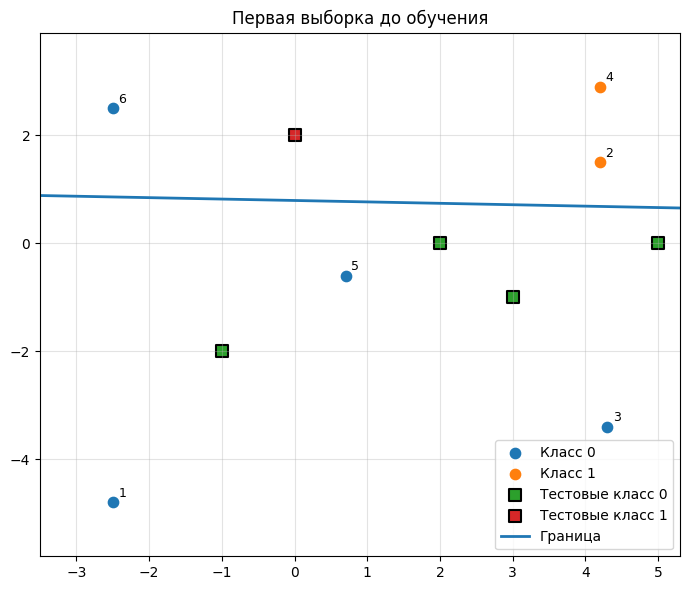

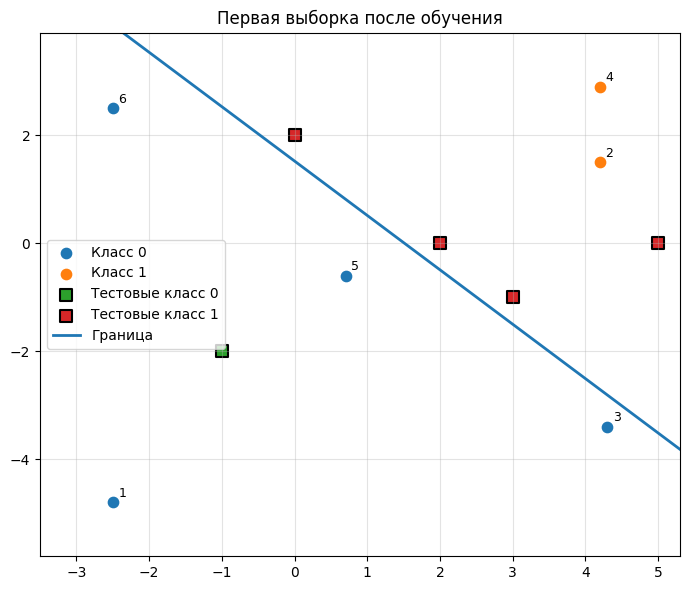

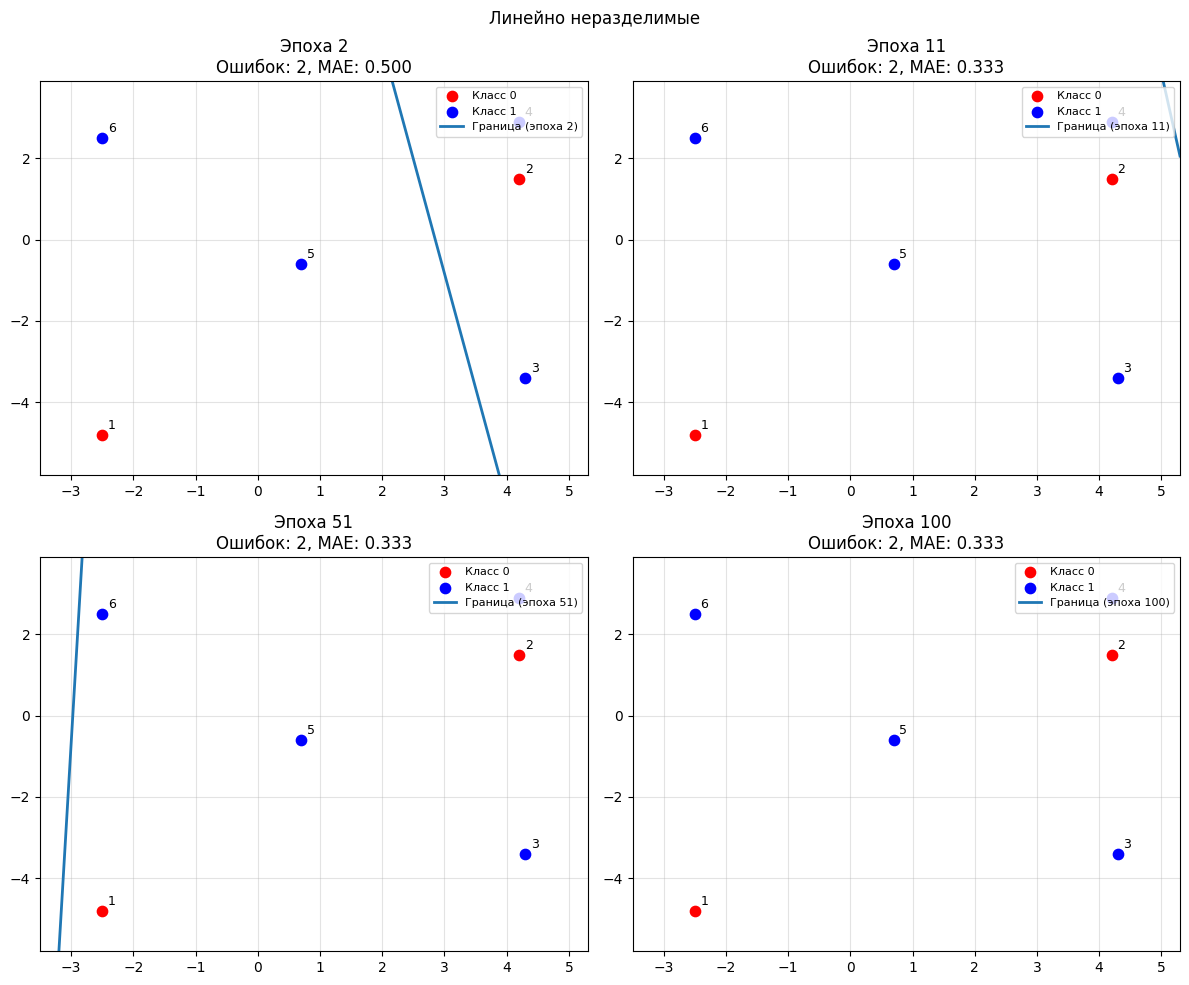

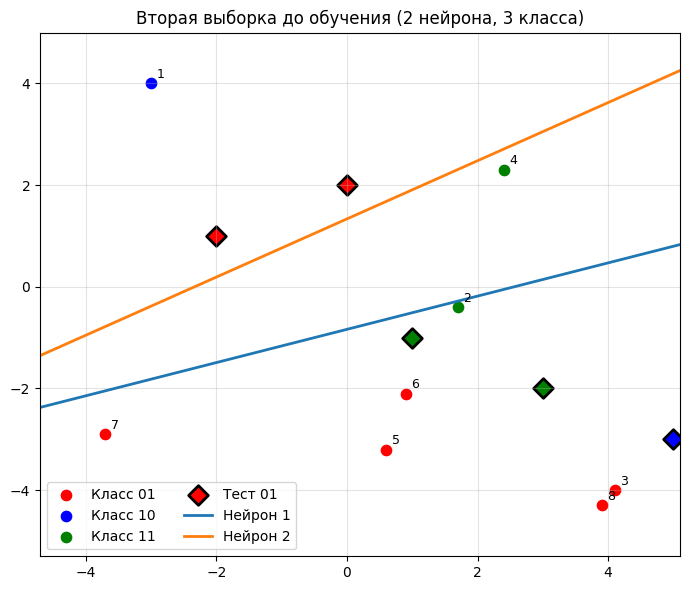

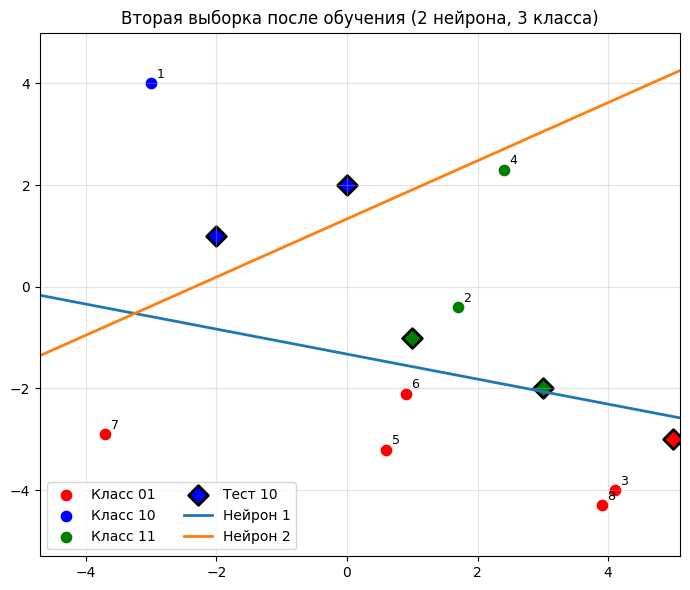

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


def hardlim(x):
    return (x >= 0).astype(int)

class RosenblattPerceptron:
    def __init__(self, n_inputs, n_outputs, lr=1.0, max_epochs=100, seed=0):
        rng = np.random.default_rng(seed)
        self.W = rng.uniform(-1, 1, (n_outputs, n_inputs))
        self.b = rng.uniform(-1, 1, (n_outputs, 1))
        self.lr = lr
        self.max_epochs = max_epochs
        self.history = []

    def predict(self, P):
        return hardlim(self.W @ P + self.b)

    def fit(self, P, T, epochs=None):
        self.history = []
        total_epochs = epochs or self.max_epochs
        q = P.shape[1]
        for epoch in range(1, total_epochs + 1):
            errors = 0
            for i in range(q):
                p = P[:, [i]]
                t = T[:, [i]]
                a = self.predict(p)
                e = t - a
                if np.any(e != 0):
                    self.W += self.lr * e @ p.T
                    self.b += self.lr * e
                    errors += int(np.sum(np.abs(e)))
            mae = float(np.mean(np.abs(T - self.predict(P))))
            self.history.append({
                'epoch': epoch,
                'W': self.W.copy(),
                'b': self.b.copy(),
                'mae': mae,
                'errors': errors,
            })
        return self

def code_of(col):
    return ''.join(map(str, np.asarray(col).reshape(-1).tolist()))

def plot_boundary(ax, W, b, label):
    x_min, x_max = ax.get_xlim()
    xs = np.linspace(x_min, x_max, 300)
    w1, w2 = W.reshape(-1)
    if abs(w2) < 1e-8:
        ax.axvline(-float(b)/w1, label=label, linewidth=2)
    else:
        ys = (-float(b) - w1*xs)/w2
        ax.plot(xs, ys, label=label, linewidth=2)

def annotate(ax, P):
    for i, (x, y) in enumerate(P.T, start=1):
        ax.annotate(str(i), (x, y), xytext=(4,4), textcoords='offset points', fontsize=9)

# Данные

X1 = np.array([[-2.5, 4.2, 4.3, 4.2, 0.7, -2.5],
               [-4.8, 1.5, -3.4, 2.9, -0.6, 2.5]])
y1 = np.array([[0, 1, 0, 1, 0, 0]])

X2 = np.array([[-3, 1.7, 4.1, 2.4, 0.6, 0.9, -3.7, 3.9],
               [4, -0.4, -4, 2.3, -3.2, -2.1, -2.9, -4.3]])
y2 = np.array([[1, 1, 0, 1, 0, 0, 0, 0],
               [0, 1, 1, 1, 1, 1, 1, 1]])

X1_test = np.array([[-1.0, 2.0, 5.0, 0.0, 3.0],
                    [-2.0, 0.0, 0.0, 2.0, -1.0]])

X2_test = np.array([[-2.0, 0.0, 3.0, 1.0, 5.0],
                    [1.0, 2.0, -2.0, -1.0, -3.0]])

net1 = RosenblattPerceptron(2, 1, seed=1)
W1_init = net1.W.copy()
b1_init = net1.b.copy()


y1_test_pred_init = net1.predict(X1_test)
net2 = RosenblattPerceptron(2, 2, seed=0)
y2_test_pred_init = net2.predict(X2_test)

net1.fit(X1, y1, epochs=50)

T1_nr = np.array([[0, 0, 1, 1, 1, 1]])
net_nr = RosenblattPerceptron(2, 1, seed=1, lr=0.5)
net_nr.fit(X1, T1_nr, epochs=100)

net2.fit(X2, y2, epochs=50)


y1_test_pred = net1.predict(X1_test)
y2_test_pred = net2.predict(X2_test)

print("Предсказания для тестовых точек первой выборки ДО обучения:")
for i in range(X1_test.shape[1]):
    print(f"  Точка ({X1_test[0,i]:.1f}, {X1_test[1,i]:.1f}) -> Класс {y1_test_pred_init[0,i]}")

print("\nПредсказания для тестовых точек первой выборки ПОСЛЕ обучения:")
for i in range(X1_test.shape[1]):
    print(f"  Точка ({X1_test[0,i]:.1f}, {X1_test[1,i]:.1f}) -> Класс {y1_test_pred[0,i]}")

print("\nПредсказания для тестовых точек второй выборки ДО обучения:")
for i in range(X2_test.shape[1]):
    code = code_of(y2_test_pred_init[:, [i]])
    print(f"  Точка ({X2_test[0,i]:.1f}, {X2_test[1,i]:.1f}) -> Класс {code}")

print("\nПредсказания для тестовых точек второй выборки ПОСЛЕ обучения:")
for i in range(X2_test.shape[1]):
    code = code_of(y2_test_pred[:, [i]])
    print(f"  Точка ({X2_test[0,i]:.1f}, {X2_test[1,i]:.1f}) -> Класс {code}")


fig, ax = plt.subplots(figsize=(7,6))
ax.grid(True, alpha=0.35)
ax.set_xlim(X1[0].min()-1, X1[0].max()+1)
ax.set_ylim(X1[1].min()-1, X1[1].max()+1)
ax.set_title('Первая выборка до обучения')

cls0 = X1[:, y1.reshape(-1)==0]
cls1 = X1[:, y1.reshape(-1)==1]
ax.scatter(cls0[0], cls0[1], s=55, label='Класс 0')
ax.scatter(cls1[0], cls1[1], s=55, label='Класс 1')
annotate(ax, X1)


test_cls0_init = X1_test[:, y1_test_pred_init.reshape(-1)==0]
test_cls1_init = X1_test[:, y1_test_pred_init.reshape(-1)==1]
if test_cls0_init.size > 0:
    ax.scatter(test_cls0_init[0], test_cls0_init[1], s=80, marker='s',
              label='Тестовые класс 0', edgecolors='black', linewidth=1.5)
if test_cls1_init.size > 0:
    ax.scatter(test_cls1_init[0], test_cls1_init[1], s=80, marker='s',
              label='Тестовые класс 1', edgecolors='black', linewidth=1.5)

plot_boundary(ax, W1_init, b1_init, 'Граница')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7,6))
ax.grid(True, alpha=0.35)
ax.set_xlim(X1[0].min()-1, X1[0].max()+1)
ax.set_ylim(X1[1].min()-1, X1[1].max()+1)
ax.set_title('Первая выборка после обучения')

ax.scatter(cls0[0], cls0[1], s=55, label='Класс 0')
ax.scatter(cls1[0], cls1[1], s=55, label='Класс 1')
annotate(ax, X1)


test_cls0 = X1_test[:, y1_test_pred.reshape(-1)==0]
test_cls1 = X1_test[:, y1_test_pred.reshape(-1)==1]
if test_cls0.size > 0:
    ax.scatter(test_cls0[0], test_cls0[1], s=80, marker='s',
              label='Тестовые класс 0', edgecolors='black', linewidth=1.5)
if test_cls1.size > 0:
    ax.scatter(test_cls1[0], test_cls1[1], s=80, marker='s',
              label='Тестовые класс 1', edgecolors='black', linewidth=1.5)

plot_boundary(ax, net1.history[-1]['W'], net1.history[-1]['b'], 'Граница')
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

epochs_to_show = [1, 10, 50, 99]

for idx, epoch_idx in enumerate(epochs_to_show):
    ax = axes[idx]
    ax.grid(True, alpha=0.35)
    ax.set_xlim(X1[0].min()-1, X1[0].max()+1)
    ax.set_ylim(X1[1].min()-1, X1[1].max()+1)

    cls0_nr = X1[:, T1_nr.reshape(-1)==0]
    cls1_nr = X1[:, T1_nr.reshape(-1)==1]
    ax.scatter(cls0_nr[0], cls0_nr[1], s=55, color='red', label='Класс 0')
    ax.scatter(cls1_nr[0], cls1_nr[1], s=55, color='blue', label='Класс 1')
    annotate(ax, X1)

    current_W = net_nr.history[epoch_idx]['W']
    current_b = net_nr.history[epoch_idx]['b']
    plot_boundary(ax, current_W, current_b, f'Граница (эпоха {epoch_idx+1})')

    predictions = net_nr.predict(X1)
    errors = np.sum(np.abs(T1_nr - predictions))
    mae = net_nr.history[epoch_idx]['mae']

    ax.set_title(f'Эпоха {epoch_idx+1}\nОшибок: {errors}, MAE: {mae:.3f}')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Линейно неразделимые', fontsize=12)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7,6))
ax.grid(True, alpha=0.35)
ax.set_xlim(X2[0].min()-1, X2[0].max()+1)
ax.set_ylim(X2[1].min()-1, X2[1].max()+1)
ax.set_title('Вторая выборка до обучения (2 нейрона, 3 класса)')

codes = [code_of(y2[:,[i]]) for i in range(y2.shape[1])]
unique_codes = sorted(set(codes))
colors = ['red', 'blue', 'green', 'purple']

for idx, code in enumerate(unique_codes):
    idxs = [i for i, c in enumerate(codes) if c == code]
    pts = X2[:, idxs]
    ax.scatter(pts[0], pts[1], s=55, color=colors[idx%len(colors)], label=f'Класс {code}')


test_codes_init = [code_of(y2_test_pred_init[:, [i]]) for i in range(X2_test.shape[1])]
for i, (x, y) in enumerate(X2_test.T):
    code = test_codes_init[i]
    color_idx = unique_codes.index(code) if code in unique_codes else 0
    ax.scatter(x, y, s=100, marker='D', color=colors[color_idx],
              edgecolors='black', linewidth=2, label=f'Тест {code}' if i==0 else "")

annotate(ax, X2)
plot_boundary(ax, net2.history[0]['W'][0:1], net2.history[0]['b'][0:1], 'Нейрон 1')
plot_boundary(ax, net2.history[0]['W'][1:2], net2.history[0]['b'][1:2], 'Нейрон 2')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), ncol=2)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7,6))
ax.grid(True, alpha=0.35)
ax.set_xlim(X2[0].min()-1, X2[0].max()+1)
ax.set_ylim(X2[1].min()-1, X2[1].max()+1)
ax.set_title('Вторая выборка после обучения (2 нейрона, 3 класса)')

for idx, code in enumerate(unique_codes):
    idxs = [i for i, c in enumerate(codes) if c == code]
    pts = X2[:, idxs]
    ax.scatter(pts[0], pts[1], s=55, color=colors[idx%len(colors)], label=f'Класс {code}')


test_codes = [code_of(y2_test_pred[:, [i]]) for i in range(X2_test.shape[1])]
for i, (x, y) in enumerate(X2_test.T):
    code = test_codes[i]
    color_idx = unique_codes.index(code) if code in unique_codes else 0
    ax.scatter(x, y, s=100, marker='D', color=colors[color_idx],
              edgecolors='black', linewidth=2, label=f'Тест {code}' if i==0 else "")

annotate(ax, X2)
plot_boundary(ax, net2.history[-1]['W'][0:1], net2.history[-1]['b'][0:1], 'Нейрон 1')
plot_boundary(ax, net2.history[-1]['W'][1:2], net2.history[-1]['b'][1:2], 'Нейрон 2')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), ncol=2)
plt.tight_layout()
plt.show()

ЭТАП 1: КЛАССИФИКАЦИЯ ТРЕХ КЛАССОВ

Генерация исходных множеств точек...

Количество точек по классам:
Класс 1: всего 60
Класс 2: всего 100
Класс 3: всего 120

Размеры выборок:
Train: 196
Val:   56
Test:  28

Разбиение по классам:
Класс 1: train=42, val=12, test=6
Класс 2: train=70, val=20, test=10
Класс 3: train=84, val=24, test=12

Построение исходных множеств и выборок...


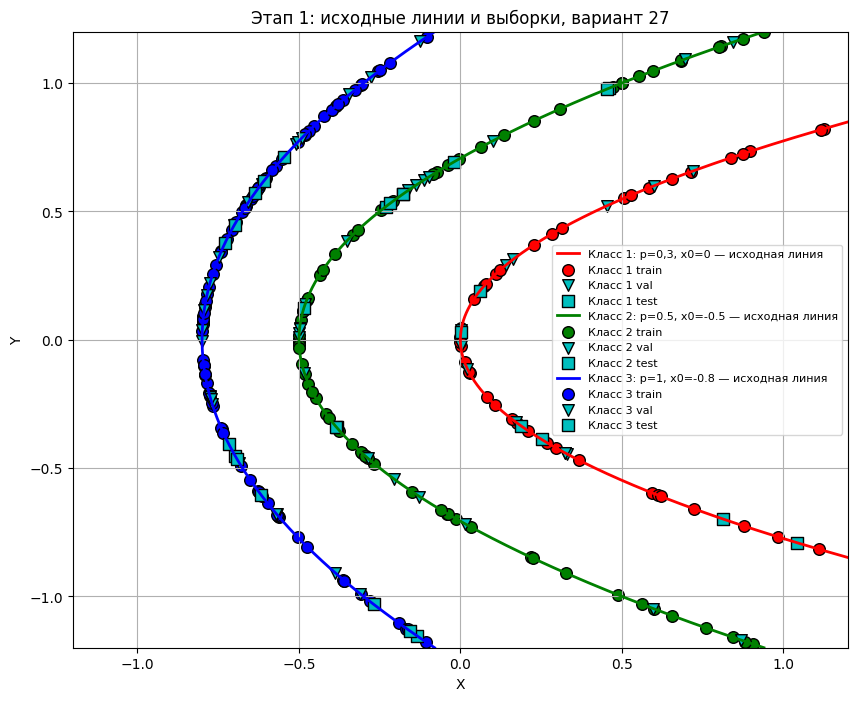


Создание нейронной сети классификации...

Обучение модели классификации...
РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ
Train: 196/196, accuracy = 100.00%
Val:   56/56, accuracy = 100.00%
Test:  28/28, accuracy = 100.00%

Матрица ошибок для test:
[[ 6  0  0]
 [ 0 10  0]
 [ 0  0 12]]


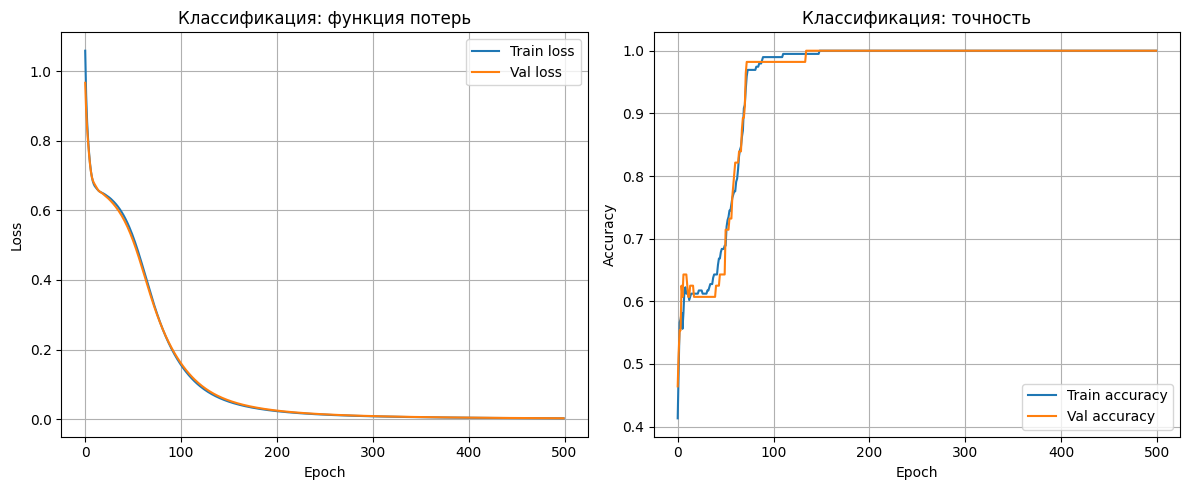

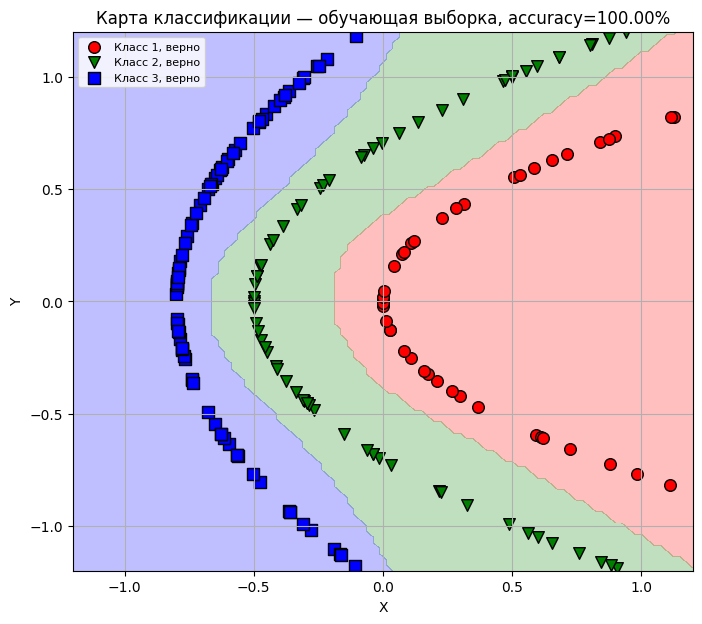

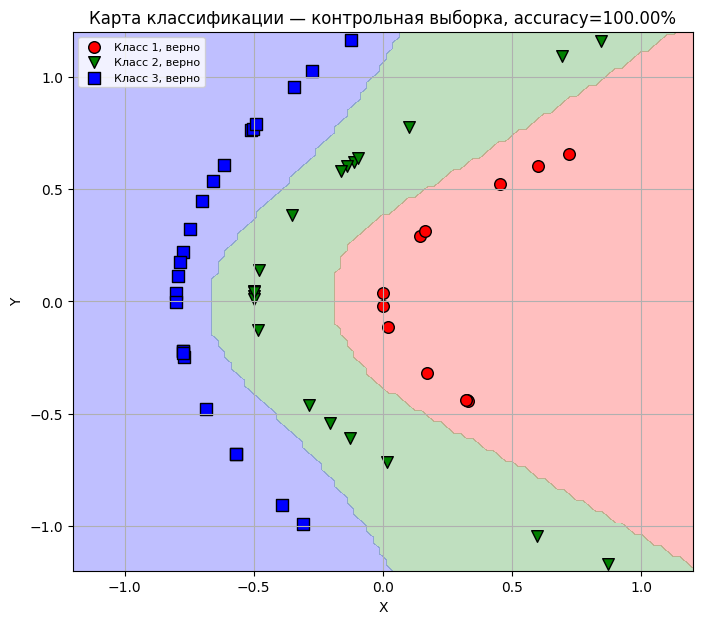

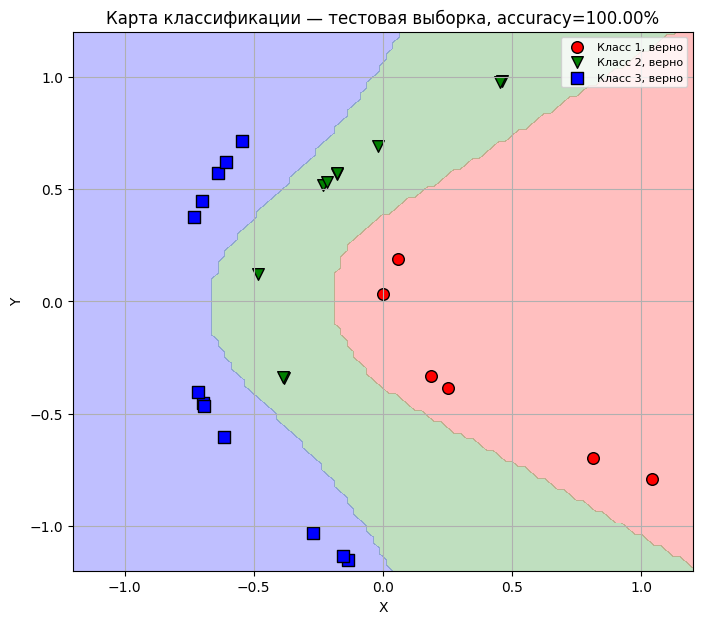

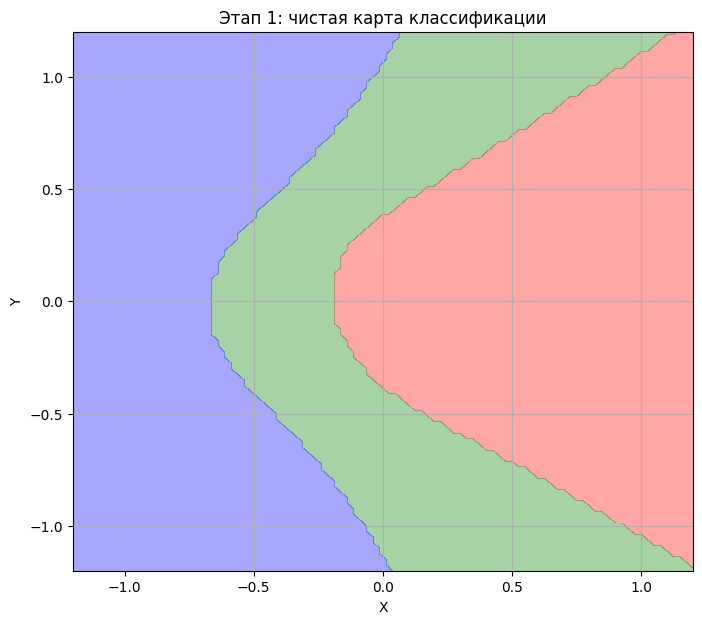

ЭТАПЫ 2 И 3: АППРОКСИМАЦИЯ
x(t) = sin(sin(t) * t^2), t ∈ [0, 3.5], h = 0.01

Всего точек: 351
Train: 315
Val:   36
Test:  0


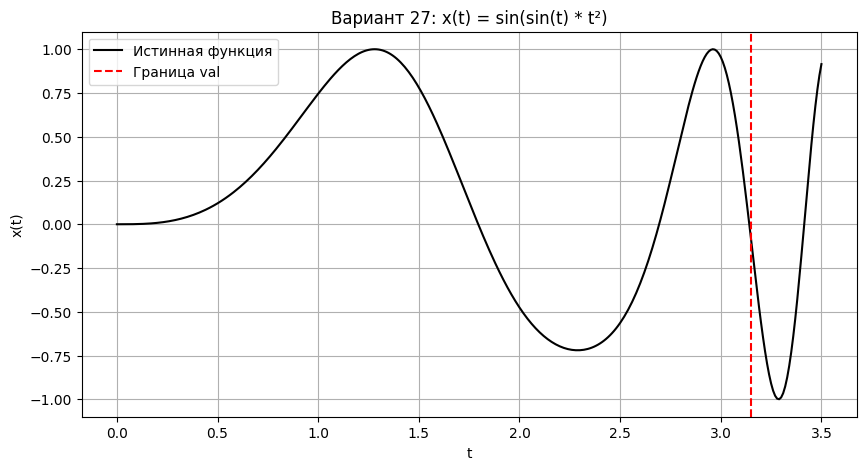

ЭТАП 2: МЕТОД ПЕРВОГО ПОРЯДКА

Epoch 354: ReduceLROnPlateau reducing learning rate to 0.03500000052154064.

Epoch 416: ReduceLROnPlateau reducing learning rate to 0.024500000104308126.

Epoch 481: ReduceLROnPlateau reducing learning rate to 0.017149999551475045.

Epoch 542: ReduceLROnPlateau reducing learning rate to 0.012004999816417693.

Epoch 584: ReduceLROnPlateau reducing learning rate to 0.008403499610722065.

Результаты этапа 2:
Train MSE: 0.28639767
Train MAE: 0.46520630
Val MSE:   0.51187638
Val MAE:   0.64495570
Время обучения: 71.30 сек


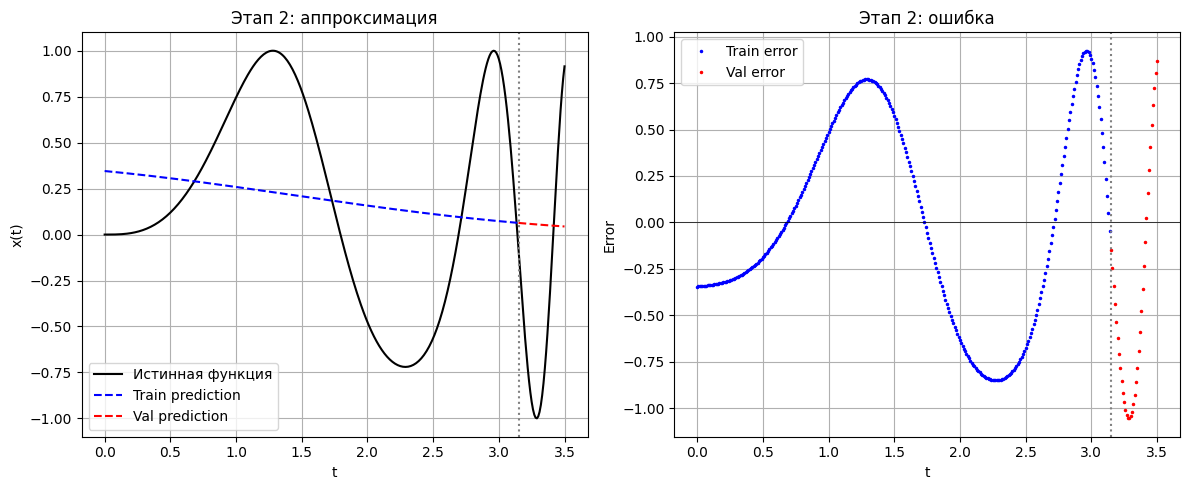

ЭТАП 3: МЕТОД ВТОРОГО ПОРЯДКА

Результаты этапа 3:
Train MSE: 0.28806528
Train MAE: 0.46667215
Val MSE:   0.49728924
Val MAE:   0.63598643
Время обучения: 14.30 сек


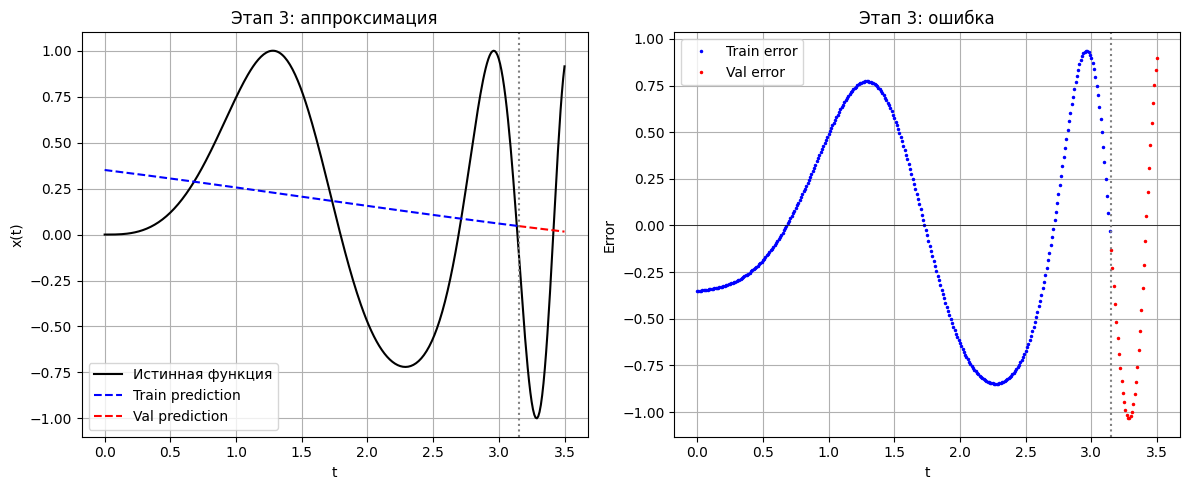

ИТОГОВЫЕ РЕЗУЛЬТАТЫ

Сравнение методов аппроксимации:
Метод                               MSE             MAE             Время, c  
Этап 2: SGD adaptive                0.30952369      0.48364214      71.30     
Этап 3: Adam                        0.30952415      0.48403772      14.30     


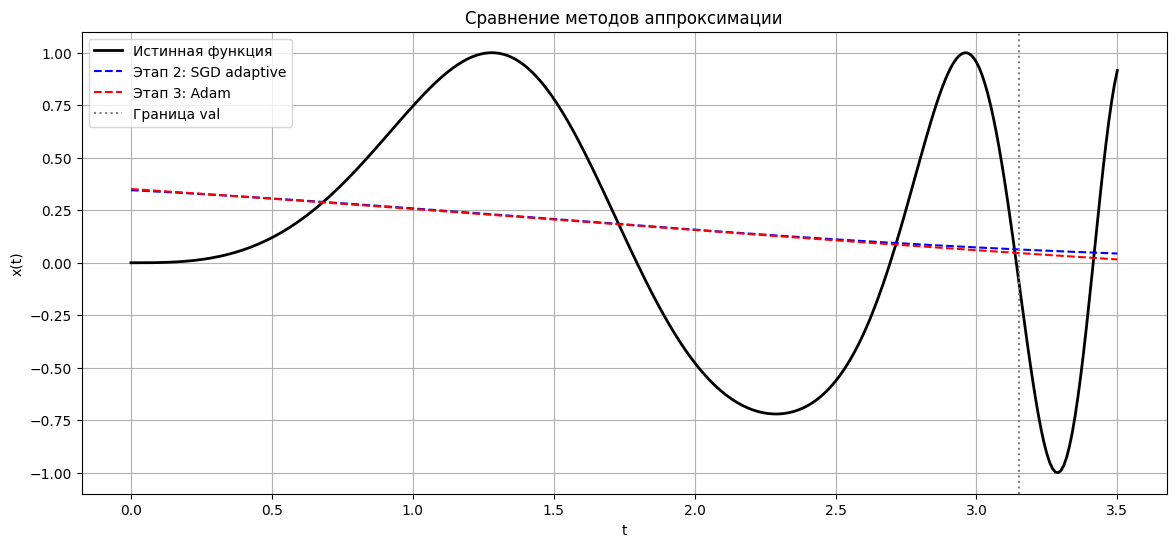


Слой 1
Матрица весов W:
[[-1.8160926e+00  1.4873072e+00  2.8028560e+00  1.5777191e+00
   1.4072901e+00  5.9725348e-02 -1.5794911e+00 -2.6767766e+00
  -1.3646803e+00 -1.5538857e+00 -4.0894270e-01  1.2394859e+00
  -2.2925475e+00 -1.2737124e+00 -2.6646152e+00  1.0953354e+00
   9.0967977e-01  2.3671510e+00 -8.7026751e-01 -1.3740355e+00]
 [-2.1211686e+00  7.9604441e-01 -1.7498469e+00  9.8532104e-01
  -3.4405439e+00 -3.0565434e-03 -9.2212397e-01  2.8380494e+00
   3.0711823e+00  2.7012200e+00  9.6694352e-03 -3.8247865e-02
  -3.2725391e+00 -2.5195675e+00  1.6206775e+00 -5.3813305e-02
  -3.3383191e-02  2.3939862e+00  1.3032249e-01 -7.6918519e-01]]
Вектор смещений b:
[-1.5160934   0.9746503   1.7082957   1.101559    1.8423035  -1.4168763
 -1.1099346  -0.584681   -1.6352719  -1.8418915   1.0818127  -0.800689
 -1.0492952  -1.1577655   0.17052473 -0.43947193 -0.7707683   0.35487363
 -0.66725576 -0.9725369 ]

Слой 2
Матрица весов W:
[[-1.9356923  -0.980565    3.4281242 ]
 [-0.16774063  1.245716   -

In [ ]:


import subprocess
import sys
import warnings
import time

warnings.filterwarnings("ignore")

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


install_package("scikit-learn")
install_package("matplotlib")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau




np.random.seed(42)
tf.random.set_seed(42)


# ЭТАП 1: КЛАССИФИКАЦИЯ

print("ЭТАП 1: КЛАССИФИКАЦИЯ ТРЕХ КЛАССОВ")

params_class = [
    {
        "p": 0.3,
        "alpha": 0.0,
        "x0": 0.0,
        "y0": 0.0,
        "n_total": 60,
        "color": "r",
        "name": "Класс 1: p=0,3, x0=0"
    },
    {
        "p": 0.5,
        "alpha": 0.0,
        "x0": -0.5,
        "y0": 0.0,
        "n_total": 100,
        "color": "g",
        "name": "Класс 2: p=0.5, x0=-0.5"
    },
    {
        "p": 1,
        "alpha": 0.0,
        "x0": -0.8,
        "y0": 0.0,
        "n_total": 120,
        "color": "b",
        "name": "Класс 3: p=1, x0=-0.8"
    }
]


def transform_points(x, y, alpha, x0, y0):
    x_rot = x * np.cos(alpha) - y * np.sin(alpha) + x0
    y_rot = x * np.sin(alpha) + y * np.cos(alpha) + y0
    return x_rot, y_rot


def generate_parabola_candidates(p, alpha, x0, y0, y_min=-1.2, y_max=1.2, n_candidates=10000):

    y = np.linspace(y_min, y_max, n_candidates)
    x = y ** 2 / (2 * p)

    x_t, y_t = transform_points(x, y, alpha, x0, y0)

    # Оставляем только точки в заданной области [-1.2, 1.2] x [-1.2, 1.2]
    mask = (
        (x_t >= -1.2) & (x_t <= 1.2) &
        (y_t >= -1.2) & (y_t <= 1.2)
    )

    return x_t[mask], y_t[mask]


def sample_points_from_curve(x, y, n_points):

    if len(x) < n_points:
        raise ValueError(
            f"Недостаточно точек для выборки: есть {len(x)}, нужно {n_points}"
        )

    idx = np.random.permutation(len(x))[:n_points]
    return x[idx], y[idx]


def split_class_points(X, y, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1):
    n = len(X)
    idx = np.random.permutation(n)

    n_train = int(round(n * train_ratio))
    n_val = int(round(n * val_ratio))
    n_test = n - n_train - n_val

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_val = X[val_idx]
    y_val = y[val_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    return X_train, y_train, X_val, y_val, X_test, y_test

# Генерация данных

print("\nГенерация исходных множеств точек...")

X_all = []
y_all = []

X_train_list = []
y_train_list = []

X_val_list = []
y_val_list = []

X_test_list = []
y_test_list = []

curves_for_plot = []

for class_idx, p in enumerate(params_class):
    x_curve, y_curve = generate_parabola_candidates(
        p=p["p"],
        alpha=p["alpha"],
        x0=p["x0"],
        y0=p["y0"]
    )

    curves_for_plot.append((x_curve, y_curve))

    # Выбираем нужное число точек из линии
    x_sample, y_sample = sample_points_from_curve(
        x_curve,
        y_curve,
        p["n_total"]
    )

    X_class_i = np.column_stack([x_sample, y_sample])
    y_class_i = np.full(p["n_total"], class_idx)

    X_all.append(X_class_i)
    y_all.append(y_class_i)

    # Делим каждый класс отдельно 70/20/10
    X_tr, y_tr, X_v, y_v, X_te, y_te = split_class_points(
        X_class_i,
        y_class_i,
        train_ratio=0.7,
        val_ratio=0.2,
        test_ratio=0.1
    )

    X_train_list.append(X_tr)
    y_train_list.append(y_tr)

    X_val_list.append(X_v)
    y_val_list.append(y_v)

    X_test_list.append(X_te)
    y_test_list.append(y_te)


# Объединяем классы в общие выборки
X_class = np.vstack(X_all)
y_class = np.hstack(y_all)

X_train = np.vstack(X_train_list)
y_train = np.hstack(y_train_list)

X_val = np.vstack(X_val_list)
y_val = np.hstack(y_val_list)

X_test = np.vstack(X_test_list)
y_test = np.hstack(y_test_list)

Y_train = tf.keras.utils.to_categorical(y_train, num_classes=3)
Y_val = tf.keras.utils.to_categorical(y_val, num_classes=3)
Y_test = tf.keras.utils.to_categorical(y_test, num_classes=3)

print("\nКоличество точек по классам:")
for i in range(3):
    print(f"Класс {i + 1}: всего {np.sum(y_class == i)}")

print("\nРазмеры выборок:")
print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

print("\nРазбиение по классам:")
for i in range(3):
    print(
        f"Класс {i + 1}: "
        f"train={np.sum(y_train == i)}, "
        f"val={np.sum(y_val == i)}, "
        f"test={np.sum(y_test == i)}"
    )


# Визуализация исходных линий и выборок

print("\nПостроение исходных множеств и выборок...")

plt.figure(figsize=(10, 8))

markers_train = ["o", "o", "o"]
markers_val = ["v", "v", "v"]
markers_test = ["s", "s", "s"]

for i, p in enumerate(params_class):
    x_curve, y_curve = curves_for_plot[i]

    # Исходная линия
    plt.plot(
        x_curve,
        y_curve,
        color=p["color"],
        linewidth=2,
        label=p["name"] + " — исходная линия"
    )

    # Train
    mask_tr = y_train == i
    plt.scatter(
        X_train[mask_tr, 0],
        X_train[mask_tr, 1],
        marker=markers_train[i],
        c=p["color"],
        edgecolors="k",
        s=70,
        label=f"Класс {i + 1} train"
    )

    # Val
    mask_v = y_val == i
    plt.scatter(
        X_val[mask_v, 0],
        X_val[mask_v, 1],
        marker=markers_val[i],
        c="c",
        edgecolors="k",
        s=70,
        label=f"Класс {i + 1} val"
    )

    # Test
    mask_te = y_test == i
    plt.scatter(
        X_test[mask_te, 0],
        X_test[mask_te, 1],
        marker=markers_test[i],
        c="c",
        edgecolors="k",
        s=70,
        label=f"Класс {i + 1} test"
    )

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Этап 1: исходные линии и выборки, вариант 27")
plt.grid(True)
plt.legend(fontsize=8, loc="best")
plt.show()


# Модель классификации


print("\nСоздание нейронной сети классификации...")

model_class = Sequential([
    Dense(20, activation="tanh", input_shape=(2,)),
    Dense(3, activation="softmax")
])

model_class.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop_class = EarlyStopping(
    monitor="val_loss",
    patience=80,
    restore_best_weights=True
)

reduce_lr_class = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=30,
    min_lr=1e-5,
    verbose=0
)

print("\nОбучение модели классификации...")
history_class = model_class.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=500,
    batch_size=64,
    verbose=0,
    callbacks=[early_stop_class, reduce_lr_class]
)


# Оценка классификации


def get_classification_result(model, X, y_true):
    pred_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(pred_proba, axis=1)
    acc = np.mean(y_pred == y_true)
    correct = np.sum(y_pred == y_true)
    total = len(y_true)
    return y_pred, acc, correct, total


pred_train, acc_train, correct_train, total_train = get_classification_result(
    model_class,
    X_train,
    y_train
)

pred_val, acc_val, correct_val, total_val = get_classification_result(
    model_class,
    X_val,
    y_val
)

pred_test, acc_test, correct_test, total_test = get_classification_result(
    model_class,
    X_test,
    y_test
)
print("РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ")

print(f"Train: {correct_train}/{total_train}, accuracy = {acc_train * 100:.2f}%")
print(f"Val:   {correct_val}/{total_val}, accuracy = {acc_val * 100:.2f}%")
print(f"Test:  {correct_test}/{total_test}, accuracy = {acc_test * 100:.2f}%")


print("\nМатрица ошибок для test:")
print(confusion_matrix(y_test, pred_test))


# Графики обучения классификатора

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_class.history["loss"], label="Train loss")
plt.plot(history_class.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Классификация: функция потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_class.history["accuracy"], label="Train accuracy")
plt.plot(history_class.history["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Классификация: точность")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Карта классификации

def plot_classification_map(model, X, y_true, y_pred, title):
    h = 0.025
    x_min, x_max = -1.2, 1.2
    y_min, y_max = -1.2, 1.2

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max + h, h),
        np.arange(y_min, y_max + h, h)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points, verbose=0)
    Z_labels = np.argmax(Z, axis=1)
    Z_img = Z_labels.reshape(xx.shape)

    plt.figure(figsize=(8, 7))
    plt.contourf(
        xx,
        yy,
        Z_img,
        alpha=0.25,
        levels=[-0.5, 0.5, 1.5, 2.5],
        colors=["red", "green", "blue"]
    )

    colors = ["r", "g", "b"]
    markers = ["o", "v", "s"]

    for i in range(3):
        mask_correct = (y_true == i) & (y_pred == i)
        mask_wrong = (y_true == i) & (y_pred != i)

        plt.scatter(
            X[mask_correct, 0],
            X[mask_correct, 1],
            c=colors[i],
            marker=markers[i],
            edgecolors="k",
            s=70,
            label=f"Класс {i + 1}, верно"
        )

        if np.any(mask_wrong):
            plt.scatter(
                X[mask_wrong, 0],
                X[mask_wrong, 1],
                c="white",
                marker=markers[i],
                edgecolors=colors[i],
                linewidths=2,
                s=90,
                label=f"Класс {i + 1}, ошибка"
            )

    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.show()


plot_classification_map(
    model_class,
    X_train,
    y_train,
    pred_train,
    f"Карта классификации — обучающая выборка, accuracy={acc_train * 100:.2f}%"
)

plot_classification_map(
    model_class,
    X_val,
    y_val,
    pred_val,
    f"Карта классификации — контрольная выборка, accuracy={acc_val * 100:.2f}%"
)

plot_classification_map(
    model_class,
    X_test,
    y_test,
    pred_test,
    f"Карта классификации — тестовая выборка, accuracy={acc_test * 100:.2f}%"
)


# Чистая карта классификации
h = 0.025
xx, yy = np.meshgrid(
    np.arange(-1.2, 1.2 + h, h),
    np.arange(-1.2, 1.2 + h, h)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model_class.predict(grid_points, verbose=0)
Z_labels = np.argmax(Z, axis=1)
Z_img = Z_labels.reshape(xx.shape)

plt.figure(figsize=(8, 7))
plt.contourf(
    xx,
    yy,
    Z_img,
    alpha=0.35,
    levels=[-0.5, 0.5, 1.5, 2.5],
    colors=["red", "green", "blue"]
)

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Этап 1: чистая карта классификации")
plt.grid(True)
plt.show()



# ЭТАПЫ 2 И 3


print("ЭТАПЫ 2 И 3: АППРОКСИМАЦИЯ")
print("x(t) = sin(sin(t) * t^2), t ∈ [0, 3.5], h = 0.01")


# Генерация данных для аппроксимации


t_start = 0.0
t_end = 3.5
h = 0.01

t = np.arange(t_start, t_end + h, h).reshape(-1, 1)
x_func = np.sin(np.sin(t) * t ** 2)


t_norm = (t - t_start) / (t_end - t_start)

split_idx = int(len(t_norm) * 0.9)

t_train = t_norm[:split_idx]
x_train = x_func[:split_idx]

t_val = t_norm[split_idx:]
x_val = x_func[split_idx:]

print(f"\nВсего точек: {len(t)}")
print(f"Train: {len(t_train)}")
print(f"Val:   {len(t_val)}")
print(f"Test:  0")


# Визуализация исходной функции

plt.figure(figsize=(10, 5))
plt.plot(t, x_func, "k-", linewidth=1.5, label="Истинная функция")
plt.axvline(t[split_idx], color="r", linestyle="--", label="Граница val")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Вариант 27: x(t) = sin(sin(t) * t²)")
plt.grid(True)
plt.legend()
plt.show()


# Создание модели аппроксимации

def create_approx_model(hidden_neurons=10):
    model = Sequential([
        Dense(hidden_neurons, activation="tanh", input_shape=(1,)),
        Dense(1, activation="linear")
    ])
    return model

# ЭТАП 2: Метод первого порядка — аналог traingda

print("ЭТАП 2: МЕТОД ПЕРВОГО ПОРЯДКА")

model_order1 = create_approx_model(hidden_neurons=10)

model_order1.compile(
    optimizer=SGD(learning_rate=0.05),
    loss="mse",
    metrics=["mae"]
)

early_stop_o1 = EarlyStopping(
    monitor="val_loss",
    patience=100,
    restore_best_weights=True
)

reduce_lr_o1 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.7,
    patience=30,
    min_lr=1e-6,
    verbose=1
)

start_time = time.time()

history_order1 = model_order1.fit(
    t_train,
    x_train,
    validation_data=(t_val, x_val),
    epochs=600,
    batch_size=64,
    verbose=0,
    callbacks=[early_stop_o1, reduce_lr_o1]
)

train_time_order1 = time.time() - start_time

x_train_pred_o1 = model_order1.predict(t_train, verbose=0).flatten()
x_val_pred_o1 = model_order1.predict(t_val, verbose=0).flatten()

mse_train_o1 = mean_squared_error(x_train, x_train_pred_o1)
mae_train_o1 = mean_absolute_error(x_train, x_train_pred_o1)

mse_val_o1 = mean_squared_error(x_val, x_val_pred_o1)
mae_val_o1 = mean_absolute_error(x_val, x_val_pred_o1)

print("\nРезультаты этапа 2:")
print(f"Train MSE: {mse_train_o1:.8f}")
print(f"Train MAE: {mae_train_o1:.8f}")
print(f"Val MSE:   {mse_val_o1:.8f}")
print(f"Val MAE:   {mae_val_o1:.8f}")
print(f"Время обучения: {train_time_order1:.2f} сек")


# Визуализация этапа 2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, x_func, "k-", label="Истинная функция")
plt.plot(t_train * (t_end - t_start) + t_start, x_train_pred_o1, "b--", label="Train prediction")
plt.plot(t_val * (t_end - t_start) + t_start, x_val_pred_o1, "r--", label="Val prediction")
plt.axvline(t[split_idx], color="gray", linestyle=":")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Этап 2: аппроксимация")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    t_train * (t_end - t_start) + t_start,
    x_train.flatten() - x_train_pred_o1,
    "b.",
    markersize=3,
    label="Train error"
)
plt.plot(
    t_val * (t_end - t_start) + t_start,
    x_val.flatten() - x_val_pred_o1,
    "r.",
    markersize=3,
    label="Val error"
)
plt.axhline(0, color="k", linewidth=0.5)
plt.axvline(t[split_idx], color="gray", linestyle=":")
plt.xlabel("t")
plt.ylabel("Error")
plt.title("Этап 2: ошибка")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# ЭТАП 3: Метод второго порядка


print("ЭТАП 3: МЕТОД ВТОРОГО ПОРЯДКА")

model_order2 = create_approx_model(hidden_neurons=10)

model_order2.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

early_stop_o2 = EarlyStopping(
    monitor="val_loss",
    patience=100,
    restore_best_weights=True
)

reduce_lr_o2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=30,
    min_lr=1e-6,
    verbose=0
)

start_time = time.time()

history_order2 = model_order2.fit(
    t_train,
    x_train,
    validation_data=(t_val, x_val),
    epochs=600,
    batch_size=64,
    verbose=0,
    callbacks=[early_stop_o2, reduce_lr_o2]
)

train_time_order2 = time.time() - start_time

x_train_pred_o2 = model_order2.predict(t_train, verbose=0).flatten()
x_val_pred_o2 = model_order2.predict(t_val, verbose=0).flatten()

mse_train_o2 = mean_squared_error(x_train, x_train_pred_o2)
mae_train_o2 = mean_absolute_error(x_train, x_train_pred_o2)

mse_val_o2 = mean_squared_error(x_val, x_val_pred_o2)
mae_val_o2 = mean_absolute_error(x_val, x_val_pred_o2)

print("\nРезультаты этапа 3:")
print(f"Train MSE: {mse_train_o2:.8f}")
print(f"Train MAE: {mae_train_o2:.8f}")
print(f"Val MSE:   {mse_val_o2:.8f}")
print(f"Val MAE:   {mae_val_o2:.8f}")
print(f"Время обучения: {train_time_order2:.2f} сек")



# Визуализация этапа 3
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, x_func, "k-", label="Истинная функция")
plt.plot(t_train * (t_end - t_start) + t_start, x_train_pred_o2, "b--", label="Train prediction")
plt.plot(t_val * (t_end - t_start) + t_start, x_val_pred_o2, "r--", label="Val prediction")
plt.axvline(t[split_idx], color="gray", linestyle=":")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Этап 3: аппроксимация")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    t_train * (t_end - t_start) + t_start,
    x_train.flatten() - x_train_pred_o2,
    "b.",
    markersize=3,
    label="Train error"
)
plt.plot(
    t_val * (t_end - t_start) + t_start,
    x_val.flatten() - x_val_pred_o2,
    "r.",
    markersize=3,
    label="Val error"
)
plt.axhline(0, color="k", linewidth=0.5)
plt.axvline(t[split_idx], color="gray", linestyle=":")
plt.xlabel("t")
plt.ylabel("Error")
plt.title("Этап 3: ошибка")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Итоговое сравнение


print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")


x_full_pred_o1 = model_order1.predict(t_norm, verbose=0).flatten()
x_full_pred_o2 = model_order2.predict(t_norm, verbose=0).flatten()

mse_full_o1 = mean_squared_error(x_func, x_full_pred_o1)
mae_full_o1 = mean_absolute_error(x_func, x_full_pred_o1)

mse_full_o2 = mean_squared_error(x_func, x_full_pred_o2)
mae_full_o2 = mean_absolute_error(x_func, x_full_pred_o2)

print("\nСравнение методов аппроксимации:")

print(f"{'Метод':<35} {'MSE':<15} {'MAE':<15} {'Время, c':<10}")

print(f"{'Этап 2: SGD adaptive':<35} {mse_full_o1:<15.8f} {mae_full_o1:<15.8f} {train_time_order1:<10.2f}")
print(f"{'Этап 3: Adam':<35} {mse_full_o2:<15.8f} {mae_full_o2:<15.8f} {train_time_order2:<10.2f}")


plt.figure(figsize=(14, 6))
plt.plot(t, x_func, "k-", linewidth=2, label="Истинная функция")
plt.plot(t, x_full_pred_o1, "b--", linewidth=1.5, label="Этап 2: SGD adaptive")
plt.plot(t, x_full_pred_o2, "r--", linewidth=1.5, label="Этап 3: Adam")
plt.axvline(t[split_idx], color="gray", linestyle=":", label="Граница val")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Сравнение методов аппроксимации")
plt.grid(True)
plt.legend()
plt.show()


def print_model_weights(model, title):

    for layer_idx, layer in enumerate(model.layers):
        weights = layer.get_weights()

        if len(weights) == 0:
            continue

        W, b = weights

        print(f"\nСлой {layer_idx + 1}")
        print("Матрица весов W:")
        print(W)
        print("Вектор смещений b:")
        print(b)


print_model_weights(model_class, "Веса и смещения классификационной сети")
print_model_weights(model_order1, "Веса и смещения сети этапа 2")
print_model_weights(model_order2, "Веса и смещения сети этапа 3")



ЭТАП 1: КЛАССИФИКАЦИЯ ТРЕХ КЛАССОВ

Количество точек по классам:
Класс 1: всего 60
Класс 2: всего 100
Класс 3: всего 120

Размеры выборок:
Train: 196
Val:   56
Test:  28


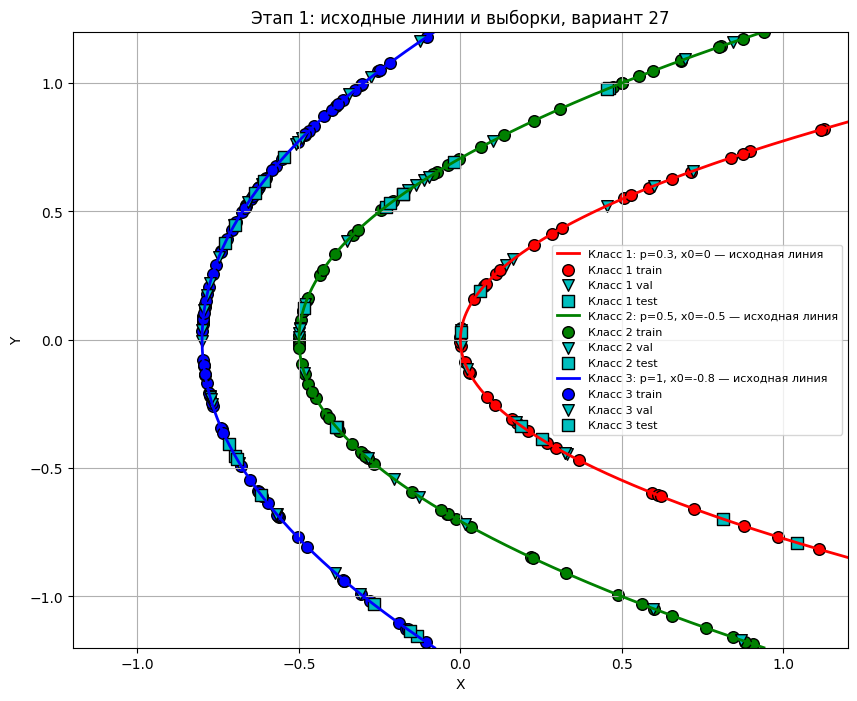


РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ
Train: 196/196, accuracy = 100.00%
Val:   56/56, accuracy = 100.00%
Test:  28/28, accuracy = 100.00%

Матрица ошибок для test:
[[ 6  0  0]
 [ 0 10  0]
 [ 0  0 12]]


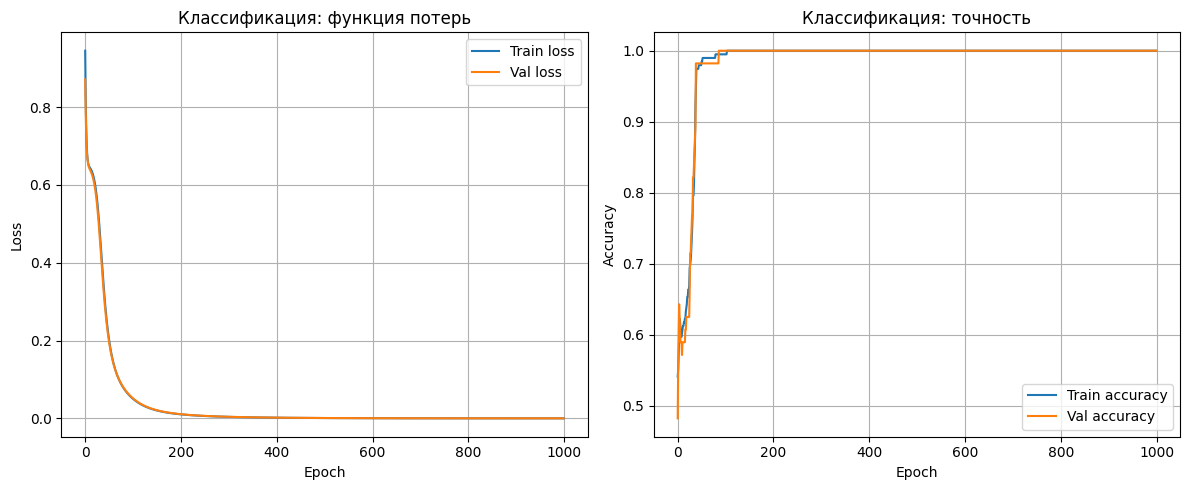

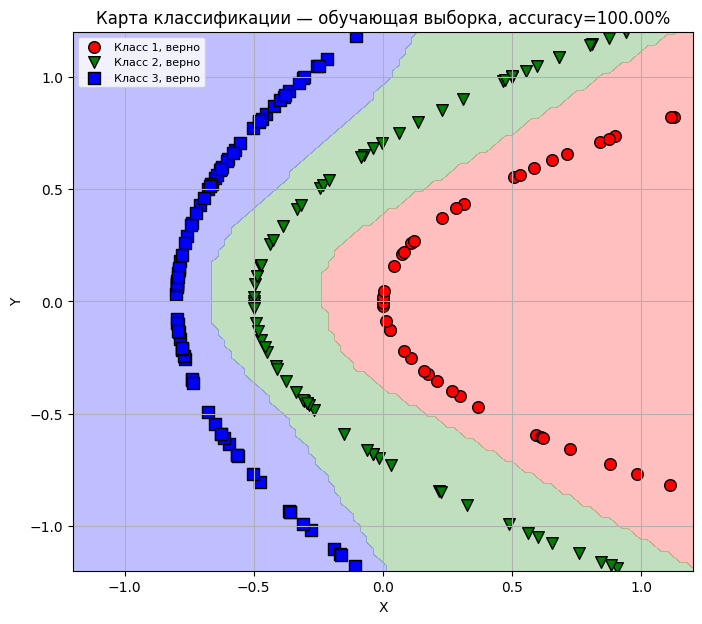

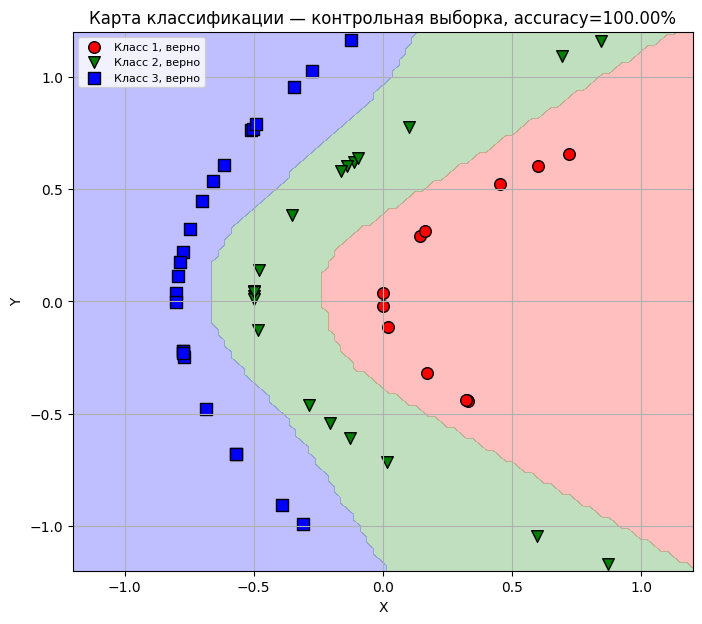

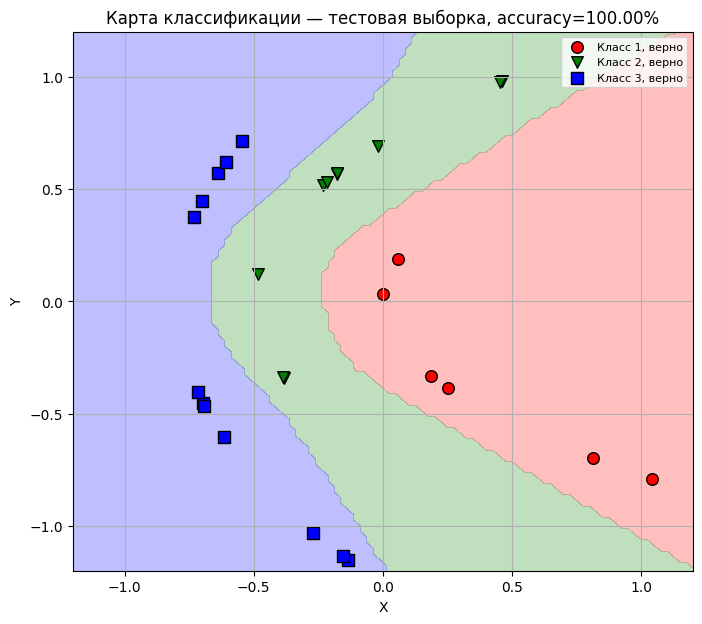

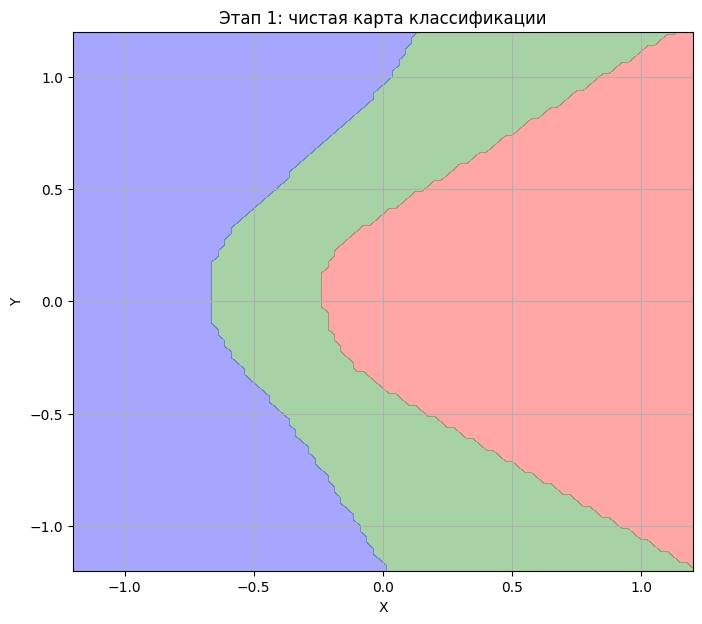


ЭТАПЫ 2 И 3: АППРОКСИМАЦИЯ
x(t) = sin(t^2 - 5t + 6), t ∈ [0, 6], h = 0.02

Всего точек: 301
Train: 270
Val:   31
Test:  0


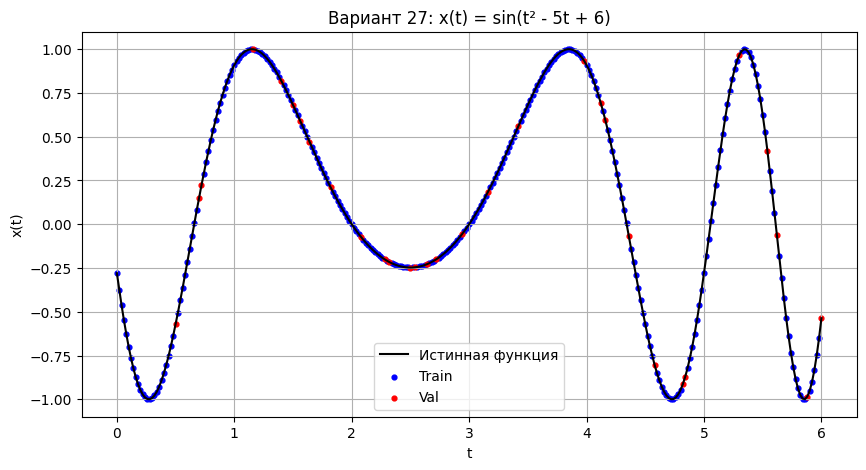


ЭТАП 2: МЕТОД ПЕРВОГО ПОРЯДКА

Epoch 2289: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 2371: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 2451: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.

Epoch 2531: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.

Epoch 2611: ReduceLROnPlateau reducing learning rate to 0.0003124999930150807.

Epoch 2691: ReduceLROnPlateau reducing learning rate to 0.00015624999650754035.

Результаты этапа 2:
Train MSE: 0.00076282
Train MAE: 0.01447712
Val MSE:   0.00349822
Val MAE:   0.02371877
Время обучения: 336.73 сек


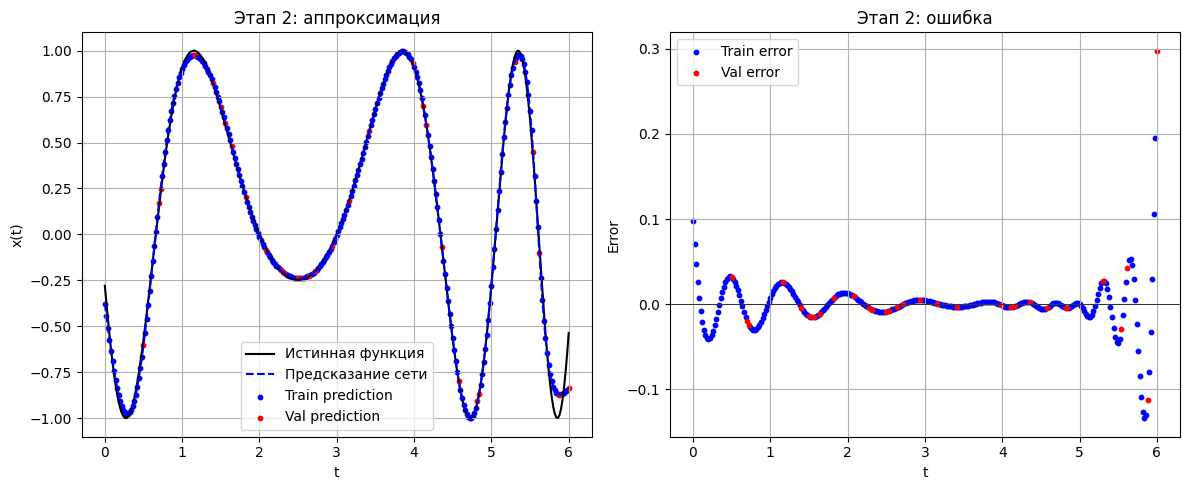


ЭТАП 3: МЕТОД ВТОРОГО ПОРЯДКА

Результаты этапа 3:
Train MSE: 0.00003399
Train MAE: 0.00378172
Val MSE:   0.00027262
Val MAE:   0.00680385
Время обучения: 375.32 сек


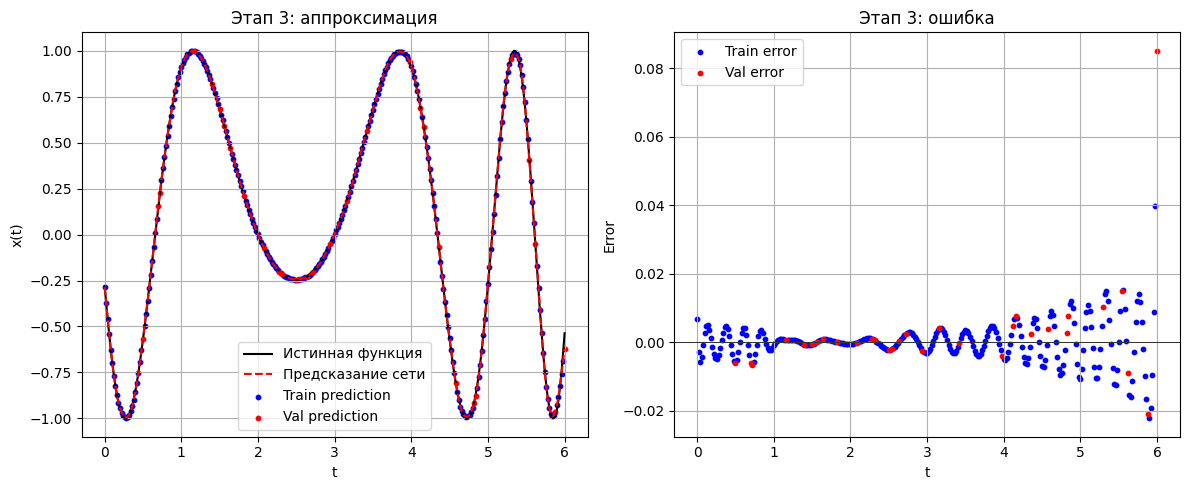


ИТОГОВЫЕ РЕЗУЛЬТАТЫ

Сравнение методов аппроксимации:
Метод                               MSE             MAE             Время, c  
Этап 2: SGD adaptive                0.00104454      0.01542891      336.73    
Этап 3: Adam                        0.00005857      0.00409296      375.32    


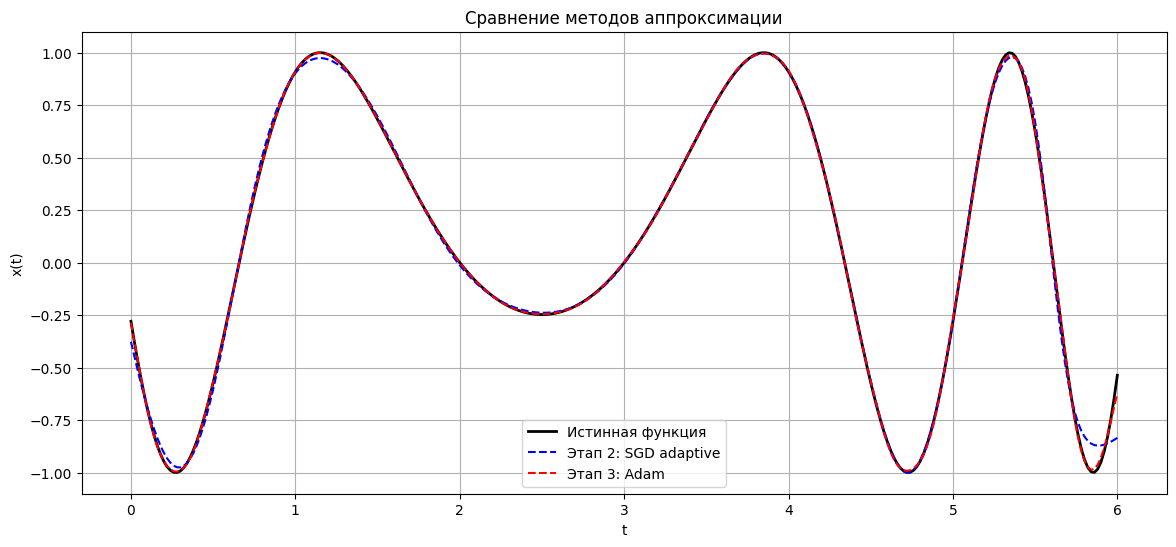


Веса и смещения классификационной сети

Слой 1
Матрица весов W:
[[-1.2766759   0.9042419   0.11995031 -1.6531211   2.3785028   0.9266573
   0.96523905 -1.0514793  -0.17667784 -0.18010613  2.220407   -3.1480536
   0.9431704  -2.0343654   3.0007067   1.6893917   0.17465562 -1.0181627
  -3.6079702   1.3497925 ]
 [-0.78898215  0.0315523  -0.0913782   4.139319   -4.152028    0.0576256
   0.05324684 -0.71426946  0.08567566  0.07132358  2.0959415  -3.656766
   0.07010062 -4.0217986  -2.9266706  -1.4304594  -0.08274976 -0.07985095
  -2.2199562  -0.8284653 ]]
Вектор смещений b:
[-0.68695295 -0.40282857 -1.7063109  -3.1025662   1.9683672  -0.93611085
  0.16029166 -0.66790843  1.2256478   1.5897938   2.0569627  -0.9661062
 -0.68129826 -1.8540618   0.4940748   1.2563022  -1.3153015  -0.13150582
 -2.3529198   0.7372846 ]

Слой 2
Матрица весов W:
[[-0.18964395 -0.53033113  2.4075816 ]
 [ 0.6493476   0.71088606 -1.8558136 ]
 [ 2.3673463  -0.48671114 -1.7278162 ]
 [-2.808111   -0.76816887  6.4524555 

In [ ]:
import subprocess
import sys
import warnings
import time

warnings.filterwarnings("ignore")

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_package("scikit-learn")
install_package("matplotlib")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

print("ЭТАП 1: КЛАССИФИКАЦИЯ ТРЕХ КЛАССОВ")

params_class = [
    {"p": 0.3, "alpha": 0.0, "x0": 0.0, "y0": 0.0, "n_total": 60, "color": "r", "name": "Класс 1: p=0.3, x0=0"},
    {"p": 0.5, "alpha": 0.0, "x0": -0.5, "y0": 0.0, "n_total": 100, "color": "g", "name": "Класс 2: p=0.5, x0=-0.5"},
    {"p": 1.0, "alpha": 0.0, "x0": -0.8, "y0": 0.0, "n_total": 120, "color": "b", "name": "Класс 3: p=1, x0=-0.8"}
]

def transform_points(x, y, alpha, x0, y0):
    x_rot = x * np.cos(alpha) - y * np.sin(alpha) + x0
    y_rot = x * np.sin(alpha) + y * np.cos(alpha) + y0
    return x_rot, y_rot

def generate_parabola_candidates(p, alpha, x0, y0, y_min=-1.2, y_max=1.2, n_candidates=10000):
    y = np.linspace(y_min, y_max, n_candidates)
    x = y ** 2 / (2 * p)
    x_t, y_t = transform_points(x, y, alpha, x0, y0)
    mask = (x_t >= -1.2) & (x_t <= 1.2) & (y_t >= -1.2) & (y_t <= 1.2)
    return x_t[mask], y_t[mask]

def sample_points_from_curve(x, y, n_points):
    idx = np.random.permutation(len(x))[:n_points]
    return x[idx], y[idx]

def split_class_points(X, y):
    n = len(X)
    idx = np.random.permutation(n)
    n_train = int(round(n * 0.7))
    n_val = int(round(n * 0.2))
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx]

X_all = []
y_all = []
X_train_list = []
y_train_list = []
X_val_list = []
y_val_list = []
X_test_list = []
y_test_list = []
curves_for_plot = []

for class_idx, p in enumerate(params_class):
    x_curve, y_curve = generate_parabola_candidates(p["p"], p["alpha"], p["x0"], p["y0"])
    curves_for_plot.append((x_curve, y_curve))
    x_sample, y_sample = sample_points_from_curve(x_curve, y_curve, p["n_total"])
    X_class_i = np.column_stack([x_sample, y_sample])
    y_class_i = np.full(p["n_total"], class_idx)

    X_all.append(X_class_i)
    y_all.append(y_class_i)

    X_tr, y_tr, X_v, y_v, X_te, y_te = split_class_points(X_class_i, y_class_i)

    X_train_list.append(X_tr)
    y_train_list.append(y_tr)
    X_val_list.append(X_v)
    y_val_list.append(y_v)
    X_test_list.append(X_te)
    y_test_list.append(y_te)

X_class = np.vstack(X_all)
y_class = np.hstack(y_all)
X_train = np.vstack(X_train_list)
y_train = np.hstack(y_train_list)
X_val = np.vstack(X_val_list)
y_val = np.hstack(y_val_list)
X_test = np.vstack(X_test_list)
y_test = np.hstack(y_test_list)

Y_train = tf.keras.utils.to_categorical(y_train, num_classes=3)
Y_val = tf.keras.utils.to_categorical(y_val, num_classes=3)
Y_test = tf.keras.utils.to_categorical(y_test, num_classes=3)

print("\nКоличество точек по классам:")
for i in range(3):
    print(f"Класс {i + 1}: всего {np.sum(y_class == i)}")

print("\nРазмеры выборок:")
print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

plt.figure(figsize=(10, 8))

for i, p in enumerate(params_class):
    x_curve, y_curve = curves_for_plot[i]

    plt.plot(x_curve, y_curve, color=p["color"], linewidth=2, label=p["name"] + " — исходная линия")

    mask_tr = y_train == i
    plt.scatter(X_train[mask_tr, 0], X_train[mask_tr, 1], marker="o", c=p["color"], edgecolors="k", s=70, label=f"Класс {i + 1} train")

    mask_v = y_val == i
    plt.scatter(X_val[mask_v, 0], X_val[mask_v, 1], marker="v", c="c", edgecolors="k", s=70, label=f"Класс {i + 1} val")

    mask_te = y_test == i
    plt.scatter(X_test[mask_te, 0], X_test[mask_te, 1], marker="s", c="c", edgecolors="k", s=70, label=f"Класс {i + 1} test")

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Этап 1: исходные линии и выборки")
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

model_class = Sequential([
    Dense(20, activation="tanh", input_shape=(2,)),
    Dense(3, activation="softmax")
])

model_class.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_class = model_class.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=1000,
    batch_size=32,
    verbose=0,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=120, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=40, min_lr=1e-5)
    ]
)

def get_classification_result(model, X, y_true):
    pred_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(pred_proba, axis=1)
    acc = np.mean(y_pred == y_true)
    correct = np.sum(y_pred == y_true)
    total = len(y_true)
    return y_pred, acc, correct, total

pred_train, acc_train, correct_train, total_train = get_classification_result(model_class, X_train, y_train)
pred_val, acc_val, correct_val, total_val = get_classification_result(model_class, X_val, y_val)
pred_test, acc_test, correct_test, total_test = get_classification_result(model_class, X_test, y_test)

print("\nРЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ")
print(f"Train: {correct_train}/{total_train}, accuracy = {acc_train * 100:.2f}%")
print(f"Val:   {correct_val}/{total_val}, accuracy = {acc_val * 100:.2f}%")
print(f"Test:  {correct_test}/{total_test}, accuracy = {acc_test * 100:.2f}%")

print("\nМатрица ошибок для test:")
print(confusion_matrix(y_test, pred_test))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_class.history["loss"], label="Train loss")
plt.plot(history_class.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Классификация: функция потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_class.history["accuracy"], label="Train accuracy")
plt.plot(history_class.history["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Классификация: точность")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

def plot_classification_map(model, X, y_true, y_pred, title):
    h = 0.025
    xx, yy = np.meshgrid(np.arange(-1.2, 1.2 + h, h), np.arange(-1.2, 1.2 + h, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points, verbose=0)
    Z_labels = np.argmax(Z, axis=1)
    Z_img = Z_labels.reshape(xx.shape)

    plt.figure(figsize=(8, 7))
    plt.contourf(xx, yy, Z_img, alpha=0.25, levels=[-0.5, 0.5, 1.5, 2.5], colors=["red", "green", "blue"])

    colors = ["r", "g", "b"]
    markers = ["o", "v", "s"]

    for i in range(3):
        mask_correct = (y_true == i) & (y_pred == i)
        mask_wrong = (y_true == i) & (y_pred != i)

        plt.scatter(X[mask_correct, 0], X[mask_correct, 1], c=colors[i], marker=markers[i], edgecolors="k", s=70, label=f"Класс {i + 1}, верно")

        if np.any(mask_wrong):
            plt.scatter(X[mask_wrong, 0], X[mask_wrong, 1], c="white", marker=markers[i], edgecolors=colors[i], linewidths=2, s=90, label=f"Класс {i + 1}, ошибка")

    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.show()

plot_classification_map(model_class, X_train, y_train, pred_train, f"Карта классификации — обучающая выборка, accuracy={acc_train * 100:.2f}%")
plot_classification_map(model_class, X_val, y_val, pred_val, f"Карта классификации — контрольная выборка, accuracy={acc_val * 100:.2f}%")
plot_classification_map(model_class, X_test, y_test, pred_test, f"Карта классификации — тестовая выборка, accuracy={acc_test * 100:.2f}%")

h = 0.025
xx, yy = np.meshgrid(np.arange(-1.2, 1.2 + h, h), np.arange(-1.2, 1.2 + h, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model_class.predict(grid_points, verbose=0)
Z_img = np.argmax(Z, axis=1).reshape(xx.shape)

plt.figure(figsize=(8, 7))
plt.contourf(xx, yy, Z_img, alpha=0.35, levels=[-0.5, 0.5, 1.5, 2.5], colors=["red", "green", "blue"])
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Этап 1: чистая карта классификации")
plt.grid(True)
plt.show()

print("\nЭТАПЫ 2 И 3: АППРОКСИМАЦИЯ")
print("x(t) = sin(t^2 - 5t + 6), t ∈ [0, 6], h = 0.02")

t_start = 0.0
t_end = 6.0
h = 0.02

t = np.arange(t_start, t_end + h, h).reshape(-1, 1)
x_func = np.sin(t ** 2 - 5 * t + 6)
t_norm = (t - t_start) / (t_end - t_start)

idx = np.random.permutation(len(t_norm))
split_idx = int(len(t_norm) * 0.9)

train_idx = np.sort(idx[:split_idx])
val_idx = np.sort(idx[split_idx:])

t_train = t_norm[train_idx]
x_train = x_func[train_idx]
t_val = t_norm[val_idx]
x_val = x_func[val_idx]

print(f"\nВсего точек: {len(t)}")
print(f"Train: {len(t_train)}")
print(f"Val:   {len(t_val)}")
print("Test:  0")

plt.figure(figsize=(10, 5))
plt.plot(t, x_func, "k-", linewidth=1.5, label="Истинная функция")
plt.scatter(t[train_idx], x_train, c="b", s=12, label="Train")
plt.scatter(t[val_idx], x_val, c="r", s=12, label="Val")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Вариант 27: x(t) = sin(t² - 5t + 6)")
plt.grid(True)
plt.legend()
plt.show()

def create_approx_model(hidden_neurons=80):
    model = Sequential([
        Dense(hidden_neurons, activation="tanh", input_shape=(1,)),
        Dense(hidden_neurons, activation="tanh"),
        Dense(hidden_neurons // 2, activation="tanh"),
        Dense(1, activation="linear")
    ])
    return model

print("\nЭТАП 2: МЕТОД ПЕРВОГО ПОРЯДКА")

model_order1 = create_approx_model(hidden_neurons=80)

model_order1.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss="mse",
    metrics=["mae"]
)

start_time = time.time()

history_order1 = model_order1.fit(
    t_train,
    x_train,
    validation_data=(t_val, x_val),
    epochs=3000,
    batch_size=32,
    verbose=0,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=300, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=80, min_lr=1e-6, verbose=1)
    ]
)

train_time_order1 = time.time() - start_time

x_train_pred_o1 = model_order1.predict(t_train, verbose=0).flatten()
x_val_pred_o1 = model_order1.predict(t_val, verbose=0).flatten()
x_full_pred_o1 = model_order1.predict(t_norm, verbose=0).flatten()

mse_train_o1 = mean_squared_error(x_train, x_train_pred_o1)
mae_train_o1 = mean_absolute_error(x_train, x_train_pred_o1)
mse_val_o1 = mean_squared_error(x_val, x_val_pred_o1)
mae_val_o1 = mean_absolute_error(x_val, x_val_pred_o1)

print("\nРезультаты этапа 2:")
print(f"Train MSE: {mse_train_o1:.8f}")
print(f"Train MAE: {mae_train_o1:.8f}")
print(f"Val MSE:   {mse_val_o1:.8f}")
print(f"Val MAE:   {mae_val_o1:.8f}")
print(f"Время обучения: {train_time_order1:.2f} сек")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, x_func, "k-", label="Истинная функция")
plt.plot(t, x_full_pred_o1, "b--", label="Предсказание сети")
plt.scatter(t[train_idx], x_train_pred_o1, c="b", s=10, label="Train prediction")
plt.scatter(t[val_idx], x_val_pred_o1, c="r", s=10, label="Val prediction")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Этап 2: аппроксимация")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(t[train_idx], x_train.flatten() - x_train_pred_o1, c="b", s=10, label="Train error")
plt.scatter(t[val_idx], x_val.flatten() - x_val_pred_o1, c="r", s=10, label="Val error")
plt.axhline(0, color="k", linewidth=0.5)
plt.xlabel("t")
plt.ylabel("Error")
plt.title("Этап 2: ошибка")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("\nЭТАП 3: МЕТОД ВТОРОГО ПОРЯДКА")

model_order2 = create_approx_model(hidden_neurons=80)

model_order2.compile(
    optimizer=Adam(learning_rate=0.003),
    loss="mse",
    metrics=["mae"]
)

start_time = time.time()

history_order2 = model_order2.fit(
    t_train,
    x_train,
    validation_data=(t_val, x_val),
    epochs=3000,
    batch_size=32,
    verbose=0,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=300, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=80, min_lr=1e-6)
    ]
)

train_time_order2 = time.time() - start_time

x_train_pred_o2 = model_order2.predict(t_train, verbose=0).flatten()
x_val_pred_o2 = model_order2.predict(t_val, verbose=0).flatten()
x_full_pred_o2 = model_order2.predict(t_norm, verbose=0).flatten()

mse_train_o2 = mean_squared_error(x_train, x_train_pred_o2)
mae_train_o2 = mean_absolute_error(x_train, x_train_pred_o2)
mse_val_o2 = mean_squared_error(x_val, x_val_pred_o2)
mae_val_o2 = mean_absolute_error(x_val, x_val_pred_o2)

print("\nРезультаты этапа 3:")
print(f"Train MSE: {mse_train_o2:.8f}")
print(f"Train MAE: {mae_train_o2:.8f}")
print(f"Val MSE:   {mse_val_o2:.8f}")
print(f"Val MAE:   {mae_val_o2:.8f}")
print(f"Время обучения: {train_time_order2:.2f} сек")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, x_func, "k-", label="Истинная функция")
plt.plot(t, x_full_pred_o2, "r--", label="Предсказание сети")
plt.scatter(t[train_idx], x_train_pred_o2, c="b", s=10, label="Train prediction")
plt.scatter(t[val_idx], x_val_pred_o2, c="r", s=10, label="Val prediction")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Этап 3: аппроксимация")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(t[train_idx], x_train.flatten() - x_train_pred_o2, c="b", s=10, label="Train error")
plt.scatter(t[val_idx], x_val.flatten() - x_val_pred_o2, c="r", s=10, label="Val error")
plt.axhline(0, color="k", linewidth=0.5)
plt.xlabel("t")
plt.ylabel("Error")
plt.title("Этап 3: ошибка")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("\nИТОГОВЫЕ РЕЗУЛЬТАТЫ")

mse_full_o1 = mean_squared_error(x_func, x_full_pred_o1)
mae_full_o1 = mean_absolute_error(x_func, x_full_pred_o1)
mse_full_o2 = mean_squared_error(x_func, x_full_pred_o2)
mae_full_o2 = mean_absolute_error(x_func, x_full_pred_o2)

print("\nСравнение методов аппроксимации:")
print(f"{'Метод':<35} {'MSE':<15} {'MAE':<15} {'Время, c':<10}")
print(f"{'Этап 2: SGD adaptive':<35} {mse_full_o1:<15.8f} {mae_full_o1:<15.8f} {train_time_order1:<10.2f}")
print(f"{'Этап 3: Adam':<35} {mse_full_o2:<15.8f} {mae_full_o2:<15.8f} {train_time_order2:<10.2f}")

plt.figure(figsize=(14, 6))
plt.plot(t, x_func, "k-", linewidth=2, label="Истинная функция")
plt.plot(t, x_full_pred_o1, "b--", linewidth=1.5, label="Этап 2: SGD adaptive")
plt.plot(t, x_full_pred_o2, "r--", linewidth=1.5, label="Этап 3: Adam")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Сравнение методов аппроксимации")
plt.grid(True)
plt.legend()
plt.show()

def print_model_weights(model, title):
    print("\n" + title)
    for layer_idx, layer in enumerate(model.layers):
        weights = layer.get_weights()
        if len(weights) == 0:
            continue
        W, b = weights
        print(f"\nСлой {layer_idx + 1}")
        print("Матрица весов W:")
        print(W)
        print("Вектор смещений b:")
        print(b)

print_model_weights(model_class, "Веса и смещения классификационной сети")
print_model_weights(model_order1, "Веса и смещения сети этапа 2")
print_model_weights(model_order2, "Веса и смещения сети этапа 3")

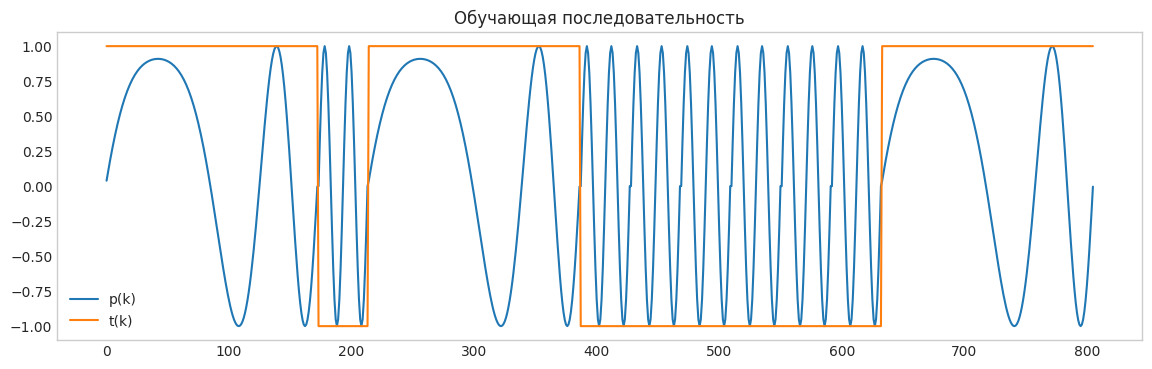

Epoch    0 | loss = 1.538950
Epoch   50 | loss = 0.906005
Epoch  100 | loss = 0.736043
Epoch  150 | loss = 0.389557
Epoch  200 | loss = 0.119891
Epoch  250 | loss = 0.069756
Epoch  300 | loss = 0.054415
Epoch  350 | loss = 0.046782
Epoch  400 | loss = 0.041469
Epoch  450 | loss = 0.038176
Epoch  500 | loss = 0.037526
Epoch  550 | loss = 0.034336
Epoch  600 | loss = 0.032378
Epoch  650 | loss = 0.030817


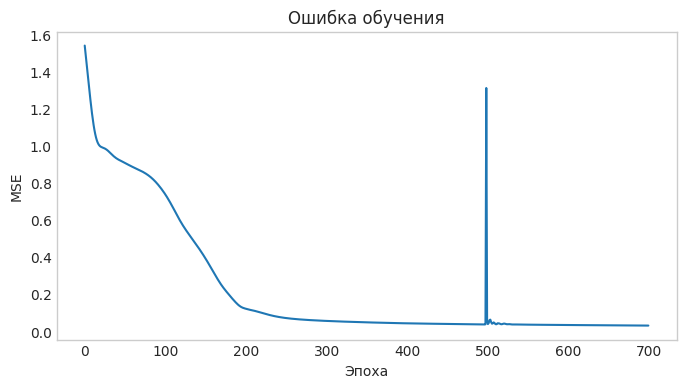

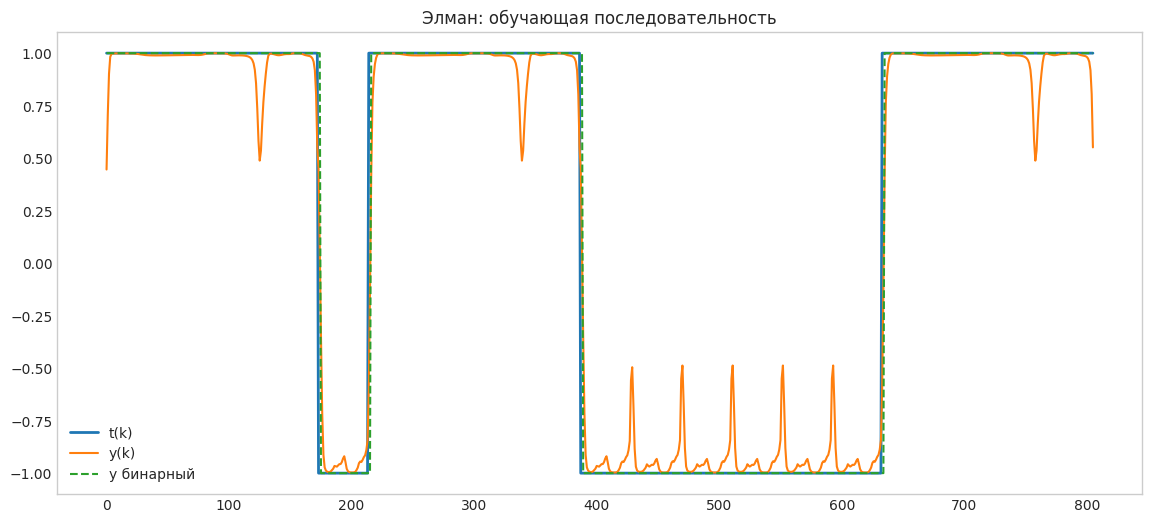

Точность на обучении: 99.0074441687345


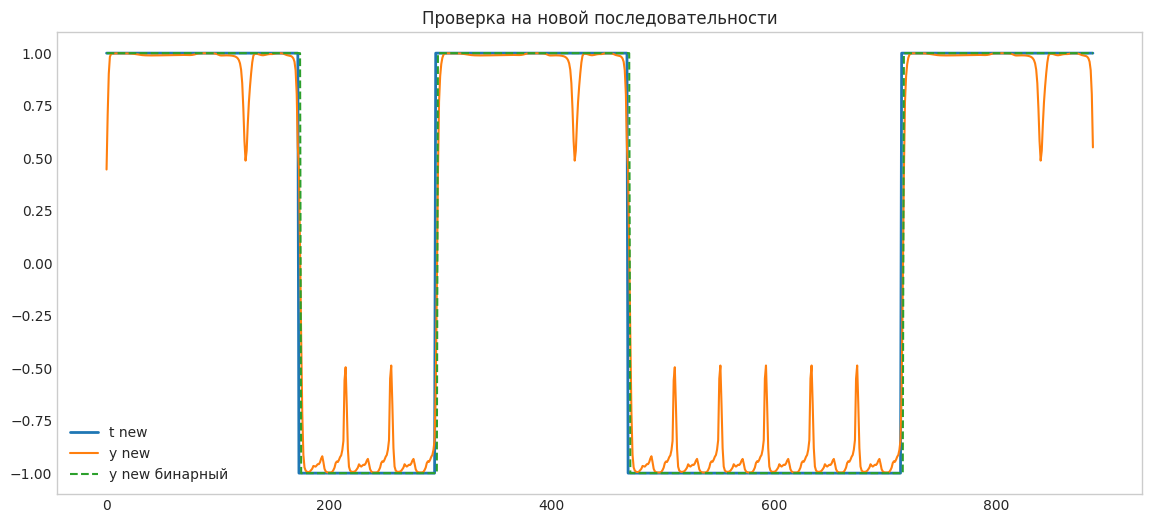

Новая точность: 99.09909909909909


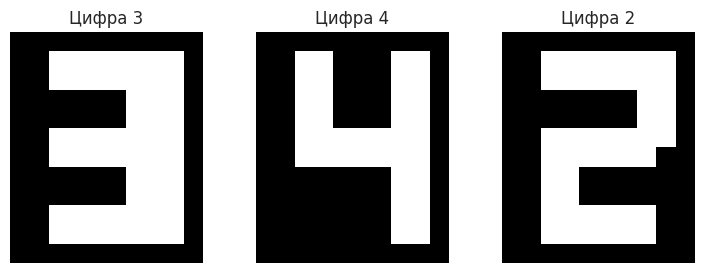


ПРОВЕРКА ХОПФИЛДА

Шум 10% | сходство с цифрой 3: 96.67%
Шум 20% | сходство с цифрой 3: 96.67%
Шум 30% | сходство с цифрой 3: 96.67%
Шум 40% | сходство с цифрой 3: 96.67%


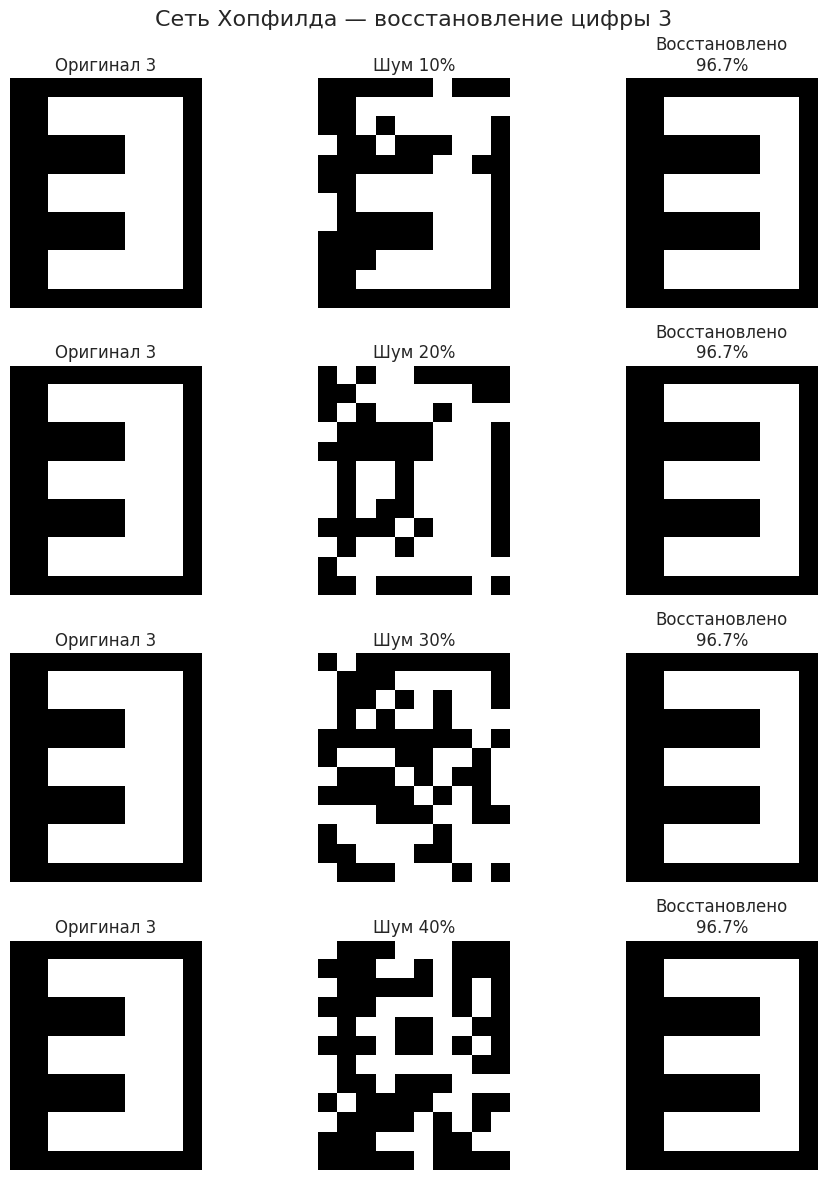


Проверка сети Хэмминга:
Вход: 3 | выходы: [39.  0.  0.] | распознано: 3
Вход: 4 | выходы: [ 0. 55.  0.] | распознано: 4
Вход: 2 | выходы: [ 0.   0.  45.5] | распознано: 2

Хэмминг для зашумленной цифры 4:
Выходы: [ 0. 43.  0.]
Распознано: 4


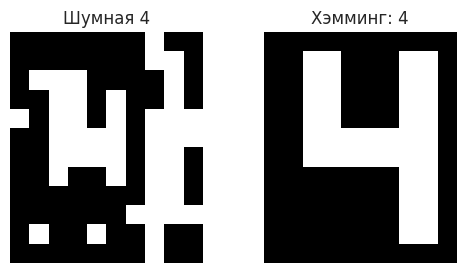

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'
np.random.seed(42)


# ЭТАП 1. СЕТЬ ЭЛМАНА


h = 0.025

k_main = np.arange(0, 1 + h, h)
p1 = np.sin(4 * np.pi * k_main)
t1 = -np.ones(len(p1))

k_g = np.arange(-0.05, 4.25 + h, h)
p2 = np.sin(k_g**2 - 2 * k_g + 3)
t2 = np.ones(len(p2))

R = [0, 1, 6]

P = np.concatenate([
    np.tile(p1, R[0]), p2,
    np.tile(p1, R[1]), p2,
    np.tile(p1, R[2]), p2
])

T = np.concatenate([
    np.tile(t1, R[0]), t2,
    np.tile(t1, R[1]), t2,
    np.tile(t1, R[2]), t2
])

plt.figure(figsize=(14, 4))
plt.plot(P, label='p(k)')
plt.plot(T, label='t(k)')
plt.legend()
plt.grid()
plt.title("Обучающая последовательность")
plt.show()


class Elman:
    def __init__(self, hidden_size=20, seed=42):
        np.random.seed(seed)

        self.hidden_size = hidden_size

        self.W_ih = np.random.randn(hidden_size, 1) * np.sqrt(1 / 1)
        self.W_hh = np.random.randn(hidden_size, hidden_size) * np.sqrt(1 / hidden_size)
        self.W_ho = np.random.randn(1, hidden_size) * np.sqrt(1 / hidden_size)

        self.b_h = np.zeros((hidden_size, 1))
        self.b_o = np.zeros((1, 1))

        self.h = np.zeros((hidden_size, 1))

        self.params = [
            self.W_ih,
            self.W_hh,
            self.W_ho,
            self.b_h,
            self.b_o
        ]

        self.m = [np.zeros_like(p) for p in self.params]
        self.v = [np.zeros_like(p) for p in self.params]
        self.adam_t = 0

    def reset(self):
        self.h = np.zeros((self.hidden_size, 1))

    def forward(self, x):
        x = np.array([[x]])
        self.h = np.tanh(self.W_ih @ x + self.W_hh @ self.h + self.b_h)
        y = np.tanh(self.W_ho @ self.h + self.b_o)
        return y

    def _adam_update(self, grads, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.adam_t += 1

        for i, (p, g) in enumerate(zip(self.params, grads)):
            self.m[i] = beta1 * self.m[i] + (1 - beta1) * g
            self.v[i] = beta2 * self.v[i] + (1 - beta2) * (g ** 2)

            m_hat = self.m[i] / (1 - beta1 ** self.adam_t)
            v_hat = self.v[i] / (1 - beta2 ** self.adam_t)

            p -= lr * m_hat / (np.sqrt(v_hat) + eps)

    def train(self, X, T, epochs=700, lr=0.001, clip_value=1.0, verbose=True):
        losses = []

        for epoch in range(epochs):
            self.reset()

            H = []
            Y = []
            Xv = []

            loss = 0

            for i in range(len(X)):
                x = np.array([[X[i]]])

                self.h = np.tanh(self.W_ih @ x + self.W_hh @ self.h + self.b_h)
                y = np.tanh(self.W_ho @ self.h + self.b_o)

                H.append(self.h.copy())
                Y.append(y.copy())
                Xv.append(x.copy())

                target = np.array([[T[i]]])
                loss += np.mean((y - target) ** 2)

            loss /= len(X)
            losses.append(loss)

            dWih = np.zeros_like(self.W_ih)
            dWhh = np.zeros_like(self.W_hh)
            dWho = np.zeros_like(self.W_ho)
            dbh = np.zeros_like(self.b_h)
            dbo = np.zeros_like(self.b_o)

            dh_next = np.zeros_like(self.h)

            for t in reversed(range(len(X))):
                y = Y[t]
                h_t = H[t]
                x = Xv[t]
                target = np.array([[T[t]]])

                dy = 2 * (y - target) * (1 - y ** 2)

                dWho += dy @ h_t.T
                dbo += dy

                dh = self.W_ho.T @ dy + dh_next
                dh_raw = dh * (1 - h_t ** 2)

                dWih += dh_raw @ x.T
                dbh += dh_raw

                h_prev = H[t - 1] if t > 0 else np.zeros_like(h_t)
                dWhh += dh_raw @ h_prev.T

                dh_next = self.W_hh.T @ dh_raw

            n = len(X)

            grads = [
                dWih / n,
                dWhh / n,
                dWho / n,
                dbh / n,
                dbo / n
            ]

            grads = [np.clip(g, -clip_value, clip_value) for g in grads]

            self._adam_update(grads, lr=lr)

            if verbose and epoch % 50 == 0:
                print(f"Epoch {epoch:4d} | loss = {loss:.6f}")

        return losses


net = Elman(hidden_size=20, seed=42)
losses = net.train(P, T, epochs=700, lr=0.001, clip_value=1.0)

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Ошибка обучения")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.grid()
plt.show()

net.reset()
Y = np.array([float(net.forward(x)) for x in P])
Yb = np.where(Y > 0, 1, -1)

plt.figure(figsize=(14, 6))
plt.plot(T, label='t(k)', linewidth=2)
plt.plot(Y, label='y(k)')
plt.plot(Yb, label='y бинарный', linestyle='--')
plt.legend()
plt.grid()
plt.title("Элман: обучающая последовательность")
plt.show()

acc = np.mean(Yb == T) * 100
print("Точность на обучении:", acc)


# Проверка на новой последовательности

R2 = [0, 3, 6]

P2 = np.concatenate([
    np.tile(p1, R2[0]), p2,
    np.tile(p1, R2[1]), p2,
    np.tile(p1, R2[2]), p2
])

T2 = np.concatenate([
    np.tile(t1, R2[0]), t2,
    np.tile(t1, R2[1]), t2,
    np.tile(t1, R2[2]), t2
])

net.reset()
Y2 = np.array([float(net.forward(x)) for x in P2])
Y2b = np.where(Y2 > 0, 1, -1)

plt.figure(figsize=(14, 6))
plt.plot(T2, label='t new', linewidth=2)
plt.plot(Y2, label='y new')
plt.plot(Y2b, label='y new бинарный', linestyle='--')
plt.legend()
plt.grid()
plt.title("Проверка на новой последовательности")
plt.show()

print("Новая точность:", np.mean(Y2b == T2) * 100)


def digit(d):
    m = -np.ones((12, 10))

    # ЦИФРА 3
    if d == 3:
        m[1:3, 2:8] = 1
        m[5:7, 2:8] = 1
        m[9:11, 2:8] = 1

        m[1:11, 7:9] = 1

        # усиливаем форму
        m[3:5, 6:8] = 1
        m[7:9, 6:8] = 1

    # ЦИФРА 4
    if d == 4:
        m[1:7, 2:4] = 1
        m[1:11, 7:9] = 1
        m[5:7, 2:9] = 1


    # ЦИФРА 2
    if d == 2:
        m[1:3, 2:8] = 1
        m[5:7, 2:8] = 1
        m[9:11, 2:8] = 1

        m[1:6, 7:9] = 1
        m[6:11, 2:4] = 1

    return m


labels = [3, 4, 2]

imgs = [
    digit(3),
    digit(4),
    digit(2)
]

vecs = [img.flatten() for img in imgs]


# ВИЗУАЛИЗАЦИЯ ЭТАЛОНОВ

plt.figure(figsize=(9, 3))

for i, img in enumerate(imgs):
    plt.subplot(1, 3, i + 1)

    plt.imshow(
        np.where(img == 1, 1, 0),
        cmap='gray'
    )

    plt.title(f"Цифра {labels[i]}")
    plt.axis('off')

plt.show()


# СЕТЬ ХОПФИЛДА

class Hopfield:

    def __init__(self, n):
        self.W = np.zeros((n, n))

    def train(self, patterns):

        self.W = np.zeros((len(patterns[0]), len(patterns[0])))


        for p in patterns:
            self.W += np.outer(p, p)
            # если p[i] == p[j], то произведение = +1 (связь усиливается)
            # - если p[i] != p[j], то произведение = -1 (связь ослабляется)
            # Суммируем по всем запоминаемым паттернам


        np.fill_diagonal(self.W, 0)

        self.W /= len(patterns)

    # СИНХРОННОЕ ОБНОВЛЕНИЕ
    def run(self, x, iterations=50):

        state = x.copy()

        for _ in range(iterations):

            new_state = np.sign(self.W @ state)

            # sign(0)=0 -> оставляем старое значение
            new_state[new_state == 0] = state[new_state == 0]

            state = new_state

        return state



# ШУМ

def noise(x, level):

    y = x.copy()

    mask = np.random.rand(len(x)) < level

    y[mask] *= -1

    return y


# ОБУЧЕНИЕ

hop = Hopfield(len(vecs[0]))

hop.train(vecs)


# ПРОВЕРКА ШУМА

print("\nПРОВЕРКА ХОПФИЛДА\n")

noise_levels = [0.1, 0.2, 0.3, 0.4]

fig, axes = plt.subplots(
    len(noise_levels),
    3,
    figsize=(10, 12)
)

for row, level in enumerate(noise_levels):

    # всегда шумим цифру 3
    noisy = noise(vecs[0], level)

    recovered = hop.run(
        noisy,
        iterations=100
    )

    similarity = np.mean(
        recovered == vecs[0]
    ) * 100

    print(
        f"Шум {int(level*100)}% "
        f"| сходство с цифрой 3: "
        f"{similarity:.2f}%"
    )

    # оригинал

    axes[row, 0].imshow(
        np.where(imgs[0] == 1, 1, 0),
        cmap='gray'
    )

    axes[row, 0].set_title(
        f"Оригинал 3"
    )

    axes[row, 0].axis('off')

    # шум

    axes[row, 1].imshow(
        np.where(
            noisy.reshape(12, 10) == 1,
            1,
            0
        ),
        cmap='gray'
    )

    axes[row, 1].set_title(
        f"Шум {int(level*100)}%"
    )

    axes[row, 1].axis('off')
    # восстановление

    axes[row, 2].imshow(
        np.where(
            recovered.reshape(12, 10) == 1,
            1,
            0
        ),
        cmap='gray'
    )

    axes[row, 2].set_title(
        f"Восстановлено\n{similarity:.1f}%"
    )

    axes[row, 2].axis('off')


plt.suptitle(
    "Сеть Хопфилда — восстановление цифры 3",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ЭТАП 3. СЕТЬ ХЭММИНГА


class Hamming:
    def __init__(self, ps):
        self.ps = np.array(ps)

        Q = len(ps)
        R = len(ps[0])

        self.IW = self.ps
        self.b1 = R * np.ones(Q)

        eps = 1 / (Q - 1)

        self.LW = -eps * np.ones((Q, Q))
        np.fill_diagonal(self.LW, 1)

    def run(self, x, it=600):
        a = self.IW @ x + self.b1

        for _ in range(it):
            a_new = np.maximum(0, self.LW @ a)

            if np.allclose(a_new, a):
                break

            a = a_new

        return a


ham = Hamming(vecs)

print("\nПроверка сети Хэмминга:")

for i, v in enumerate(vecs):
    out = ham.run(v)
    recognized = labels[np.argmax(out)]

    print(f"Вход: {labels[i]} | выходы: {out} | распознано: {recognized}")


# Проверка Хэмминга на зашумленной цифре 4

noisy4_ham = noise(vecs[1], 0.2)
out = ham.run(noisy4_ham)
recognized = labels[np.argmax(out)]

print("\nХэмминг для зашумленной цифры 4:")
print("Выходы:", out)
print("Распознано:", recognized)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(np.where(noisy4_ham.reshape(12, 10) == 1, 1, 0), cmap='gray')
plt.title("Шумная 4")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.where(imgs[labels.index(recognized)] == 1, 1, 0), cmap='gray')
plt.title(f"Хэмминг: {recognized}")
plt.axis('off')

plt.show()

Загрузка набора данных IMDB...


Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x7ceaa1445940>
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 369, in remove
    def remove(k, selfref=ref(self)):

KeyboardInterrupt: 
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 64)             │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,449 (158.00 KB)

 Trainable params: 40,449 (158.00 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5040 - loss: 0.7037 - val_accuracy: 0.5026 - val_loss: 0.6975
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5081 - loss: 0.6963 - val_accuracy: 0.4930 - val_loss: 0.7074
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5092 - loss: 0.6952 - val_accuracy: 0.4960 - val_loss: 0.7104
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5171 - loss: 0.6939 - val_accuracy: 0.5130 - val_loss: 0.6938
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5174 - loss: 0.6928 - val_accuracy: 0.5162 - val_loss: 0.6947
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5127 - loss: 0.6930 - val_accuracy: 0.5024 - val_loss: 0.6958
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5218 - loss: 0.6923 - val_accuracy: 0.4992 - val_loss: 0.6939
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5200 - loss: 0.6918 - val_accurac

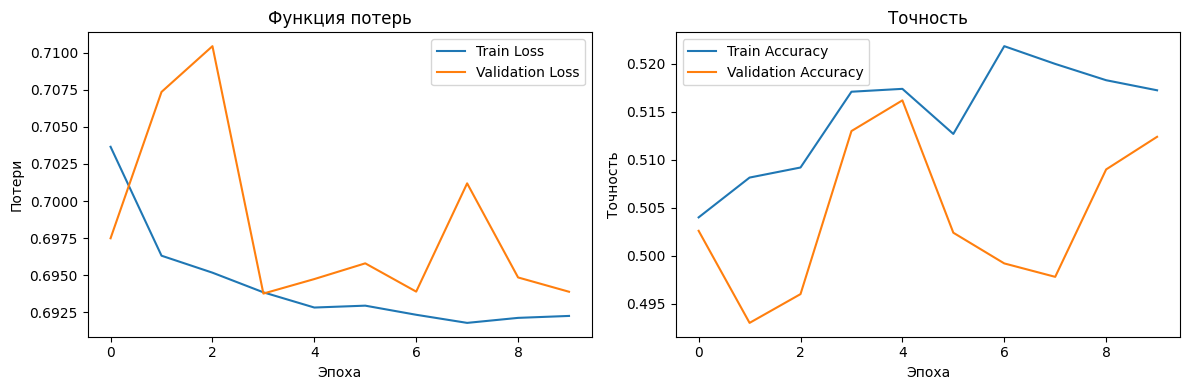

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

Предсказания на 5 тестовых примерах:
Пример 1: Предсказание = 1, Истинное значение = 0
Пример 2: Предсказание = 0, Истинное значение = 1
Пример 3: Предсказание = 1, Истинное значение = 1
Пример 4: Предсказание = 0, Истинное значение = 0
Пример 5: Предсказание = 0, Истинное значение = 1

 Сравнение с базовым классификатором 
Базовая модель (16-16, relu-relu): точность = 0.5005
Ваша модель (64-64-64, tanh-tanh-tanh): точность = 0.5062
Улучшение: 0.0057
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.metrics import accuracy_score, classification_report

# Параметры
NUM_WORDS = 10000
MAX_LEN = 500

print("Загрузка набора данных IMDB...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=NUM_WORDS)


x_train = pad_sequences(x_train, maxlen=MAX_LEN)
x_test = pad_sequences(x_test, maxlen=MAX_LEN)

# 3. Построение модели (3 слоя, 64-64-64, tanh-tanh-tanh, BinaryCrossentropy)
model = Sequential([
    Dense(64, activation='tanh', input_shape=(MAX_LEN,)),
    Dense(64, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(1, activation='sigmoid')
])

# 4. Компиляция модели
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

# 5. Вывод архитектуры
print(model.summary())

# 6. Обучение
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 7. Оценка на тестовых данных
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"\nТестовая точность: {test_accuracy:.4f}")
print(f"Тестовые потери: {test_loss:.4f}")

# 8. Графики
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Функция потерь')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Потери')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Точность')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Точность')
axes[1].legend()

plt.tight_layout()
plt.show()

# 9. Предсказание на новых данных
sample_reviews = x_test[:5]
predictions = (model.predict(sample_reviews) > 0.5).astype(int)

print("\nПредсказания на 5 тестовых примерах:")
for i, pred in enumerate(predictions):
    print(f"Пример {i+1}: Предсказание = {pred[0]}, Истинное значение = {y_test[i]}")

# 10. Сравнение с базовым классификатором (2 слоя, 16-16, relu-relu)
base_model = Sequential([
    Dense(16, activation='relu', input_shape=(MAX_LEN,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
base_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
base_history = base_model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
base_test_loss, base_test_acc = base_model.evaluate(x_test, y_test, verbose=0)

print("\n Сравнение с базовым классификатором ")
print(f"Базовая модель (16-16, relu-relu): точность = {base_test_acc:.4f}")
print(f"Ваша модель (64-64-64, tanh-tanh-tanh): точность = {test_accuracy:.4f}")
print(f"Улучшение: {test_accuracy - base_test_acc:.4f}")
print(x_train[1])

In [ ]:
print(x_train[1])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3120 - loss: 3.2166 - val_accuracy: 0.3540 - val_loss: 2.6135
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.3603 - loss: 2.3403 - val_accuracy: 0.3820 - val_loss: 2.0698
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4465 - loss: 1.9159 - val_accuracy: 0.5660 - val_loss: 1.7743
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6059 - loss: 1.6390 - val_accuracy: 0.6300 - val_loss: 1.5674
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6711 - loss: 1.4160 - val_accuracy: 0.6810 - val_loss: 1.3994
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.7269 - loss: 1.2312 - val_accuracy: 0.7050 - val_loss: 1.2789
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7585 - loss: 1.0738 - val_accuracy: 0.7100 - val_loss: 1.1929
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy:

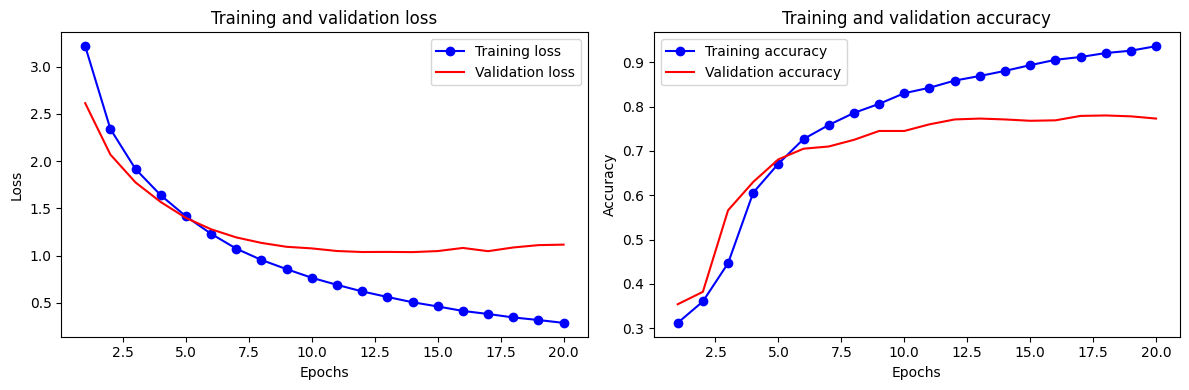

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7551 - loss: 1.2402

Точность на тестовых данных: 0.7551
Потеря на тестовых данных: 1.2402
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Предсказанный класс: 3, истинный класс: 3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# 1. Загрузка данных Reuters (только топ 10000 слов)
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=10000)

# 2. Преобразование в бинарные векторы
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results

x_train = vectorize_sequences(x_train)
x_test = vectorize_sequences(x_test)

# Количество классов (в Reuters их 46)
num_classes = max(y_train) + 1
num_classes = int(num_classes)  # явное приведение к int

# Преобразование меток в one-hot кодировку
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(10000,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(32, activation='tanh'))
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))  # 46 классов

# 4. Компиляция
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5. Выделение валидационной выборки (первые 1000 образцов)
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

# 6. Обучение
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

# 7. Графики
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(1, len(loss) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, 'bo-', label='Training loss')
plt.plot(epochs_range, val_loss, 'r-', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, 'bo-', label='Training accuracy')
plt.plot(epochs_range, val_acc, 'r-', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 8. Оценка на тесте
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nТочность на тестовых данных: {test_acc:.4f}")
print(f"Потеря на тестовых данных: {test_loss:.4f}")

# 9. Предсказание для нового примера
sample = x_test[0:1]
prediction = model.predict(sample)
predicted_class = int(np.argmax(prediction))
true_class = int(np.argmax(y_test[0]))
print(f"Предсказанный класс: {predicted_class}, истинный класс: {true_class}")

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 K-Fold Cross-Validation с K=4

Fold 1...
  Validation MAE: 2.26
Fold 2...
  Validation MAE: 2.28
Fold 3...
  Validation MAE: 2.85
Fold 4...
  Validation MAE: 2.25

Средняя MAE по 4-fold: 2.41 (+/- 0.25)

Обучение итоговой модели на всех обучающих данных 

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 473.3897 - mae: 19.6921 - val_loss: 435.5081 - val_mae: 18.6764
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 279.9438 - mae: 14.2305 - val_loss: 236.1506 - val_mae: 12.5296
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 142.8133 - mae: 8.9984 - val_loss: 128.1315 - val_mae: 8.1365
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 85.5601 - mae: 6.4193 - val_loss: 83.5321 - val_mae: 6.1349
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 64.7827 - mae: 5.4557 - val_loss: 64.7284 - val_mae: 5.4058
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 52.2717 - mae: 4.9409 - val_loss

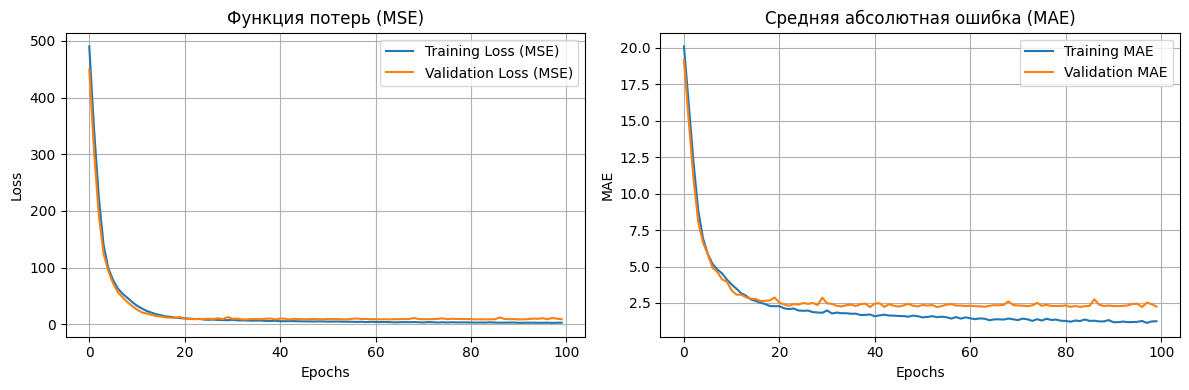


 Предсказания на новых данных 

Пример 1: Предсказано = $10.97k, Реально = $7.20k, Ошибка = $3.77k
Пример 2: Предсказано = $19.69k, Реально = $18.80k, Ошибка = $0.89k
Пример 3: Предсказано = $21.57k, Реально = $19.00k, Ошибка = $2.57k
Пример 4: Предсказано = $34.63k, Реально = $27.00k, Ошибка = $7.63k
Пример 5: Предсказано = $23.75k, Реально = $22.20k, Ошибка = $1.55k

 Сравнение с базовым классификатором 

модель
  Тестовая MAE = 3.62
  Тестовая MSE = 33.87

Базовая модель (64-64, relu-relu):
  Тестовая MAE = 2.91
  Тестовая MSE = 25.57

 Базовая модель лучше вашей


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import RMSprop

(x_train, y_train), (x_test, y_test) = boston_housing.load_data()

# 2. Нормализация данных (важно для регрессии)
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)
x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

# 3. Построение модели по варианту 27 (4 слоя: 32-32-32-32)
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(32, activation='tanh'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # выходной слой (без активации - линейный)

# 4. Компиляция
model.compile(optimizer=RMSprop(learning_rate=0.001),
              loss='mse',  # среднеквадратическая погрешность
              metrics=['mae'])  # средняя абсолютная ошибка для контроля

# 5. K-Fold Cross-Validation
from sklearn.model_selection import KFold

k = 4  # количество блоков
kfold = KFold(n_splits=k, shuffle=True, random_state=42)

history_folds = []
fold_no = 1
mae_scores = []

print(f"\n K-Fold Cross-Validation с K={k}\n")

for train_idx, val_idx in kfold.split(x_train):
    print(f"Fold {fold_no}...")

    x_train_fold = x_train[train_idx]
    y_train_fold = y_train[train_idx]
    x_val_fold = x_train[val_idx]
    y_val_fold = y_train[val_idx]

    # Создаём новую модель для каждой fold
    model_fold = Sequential()
    model_fold.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
    model_fold.add(Dense(32, activation='relu'))
    model_fold.add(Dense(32, activation='tanh'))
    model_fold.add(Dense(32, activation='relu'))
    model_fold.add(Dense(1))

    model_fold.compile(optimizer=RMSprop(learning_rate=0.001),
                       loss='mse',
                       metrics=['mae'])

    # Обучение
    history_fold = model_fold.fit(x_train_fold, y_train_fold,
                                  epochs=100,
                                  batch_size=16,
                                  validation_data=(x_val_fold, y_val_fold),
                                  verbose=0)

    # Оценка
    val_mae = model_fold.evaluate(x_val_fold, y_val_fold, verbose=0)[1]
    mae_scores.append(val_mae)
    history_folds.append(history_fold)

    print(f"  Validation MAE: {val_mae:.2f}")
    fold_no += 1

print(f"\nСредняя MAE по {k}-fold: {np.mean(mae_scores):.2f} (+/- {np.std(mae_scores):.2f})")

# 6. Обучение итоговой модели на всех данных
print("\nОбучение итоговой модели на всех обучающих данных \n")
model.fit(x_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

# 7. Оценка на тестовых данных
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f"\nТестовая MAE: {test_mae:.2f}")
print(f"Тестовая MSE: {test_loss:.2f}")

# 8. Графики обучения
history = history_folds[-1]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Функция потерь (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Средняя абсолютная ошибка (MAE)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 9. Предсказание на новых данных (первые 5 примеров из теста)
print("\n Предсказания на новых данных \n")
for i in range(5):
    pred = model.predict(x_test[i:i+1], verbose=0)[0][0]
    true = y_test[i]
    print(f"Пример {i+1}: Предсказано = ${pred:.2f}k, Реально = ${true:.2f}k, Ошибка = ${abs(pred - true):.2f}k")

# 10. Сравнение с базовым классификатором (2 слоя 64-64, relu-relu, MSE)
print("\n Сравнение с базовым классификатором \n")
base_model = Sequential()
base_model.add(Dense(64, activation='relu', input_shape=(x_train.shape[1],)))
base_model.add(Dense(64, activation='relu'))
base_model.add(Dense(1))

base_model.compile(optimizer=RMSprop(learning_rate=0.001), loss='mse', metrics=['mae'])
base_model.fit(x_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=0)
base_test_loss, base_test_mae = base_model.evaluate(x_test, y_test, verbose=0)

print(f"модель")
print(f"  Тестовая MAE = {test_mae:.2f}")
print(f"  Тестовая MSE = {test_loss:.2f}")
print(f"\nБазовая модель (64-64, relu-relu):")
print(f"  Тестовая MAE = {base_test_mae:.2f}")
print(f"  Тестовая MSE = {base_test_loss:.2f}")

if test_mae < base_test_mae:
    print("\n модель лучше базовой")
else:
    print("\n Базовая модель лучше вашей")

ЛР 6


In [ ]:
# Лабораторная работа 6
# Вариант 27 (Этап 1): 2 рекуррентных слоя, 128 нейронов, 64-64, LSTM (двунаправленная сеть)

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy

max_features = 10000
max_len = 500
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

x_train = sequence.pad_sequences(x_train, maxlen=max_len)
x_test = sequence.pad_sequences(x_test, maxlen=max_len)

model = Sequential()
model.add(Embedding(max_features, 128))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(64, return_sequences=False)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(), loss=BinaryCrossentropy(), metrics=[BinaryAccuracy()])

history = model.fit(x_train, y_train, epochs=30, batch_size=128, validation_split=0.2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['binary_accuracy'], label='Train Acc')
plt.plot(history.history['val_binary_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

sample_review = x_test[:5]
predictions = model.predict(sample_review)
print("Predictions:", predictions.flatten())

cnn_model = Sequential()
cnn_model.add(Embedding(max_features, 128))
cnn_model.add(Conv1D(128, 5, activation='relu'))
cnn_model.add(Conv1D(128, 5, activation='relu'))
cnn_model.add(Conv1D(128, 5, activation='relu'))
cnn_model.add(GlobalMaxPooling1D())
cnn_model.add(Dense(1, activation='sigmoid'))
cnn_model.compile(optimizer=Adam(), loss=BinaryCrossentropy(), metrics=[BinaryAccuracy()])
cnn_history = cnn_model.fit(x_train, y_train, epochs=30, batch_size=128, validation_split=0.2, verbose=0)

print("Bidirectional LSTM (64-64) Val Accuracy:", max(history.history['val_binary_accuracy']))
print("CNN Val Accuracy:", max(cnn_history.history['val_binary_accuracy']))

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 615s 4s/step - binary_accuracy: 0.7370 - loss: 0.5101 - val_binary_accuracy: 0.8190 - val_loss: 0.4127
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 607s 4s/step - binary_accuracy: 0.8758 - loss: 0.2987 - val_binary_accuracy: 0.8724 - val_loss: 0.3118
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 603s 4s/step - binary_accuracy: 0.9275 - loss: 0.1925 - val_binary_accuracy: 0.8644 - val_loss: 0.3463
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 603s 4s/step - binary_accuracy: 0.9524 - loss: 0.1397 - val_binary_accuracy: 0.8400 - val_loss: 0.3844
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 620s 4s/step - binary_accuracy: 0.9618 - loss: 0.1130 - val_binary_accuracy: 0.8434 - val_loss: 0.4325
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 602s 4s/step - binary_accuracy: 0.9765 - loss: 0.0760 - val_binary_accuracy: 0.8518 - val_loss: 0.4752
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 622s 4s/step - binary_accuracy: 0.9830 - loss: 0.0567 - val_binary_accuracy: 0.8482 - val_loss: 0.5378

In [ ]:
# Лабораторная работа 6
# Вариант 4 (Этап 2): 4 рекуррентных слоя, 64-32-64-32, GRU (двунаправленная сеть), прореживание 0.2

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError

def load_jena_climate_data():
    from tensorflow.keras.utils import get_file
    import os
    zip_path = get_file(
        fname='jena_climate_2009_2016.csv.zip',
        origin='https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip',
        extract=True
    )
    csv_path = os.path.join(os.path.dirname(zip_path), 'jena_climate_2009_2016.csv')
    import pandas as pd
    df = pd.read_csv(csv_path)
    return df

df = load_jena_climate_data()
temperature = df['T (degC)'].values

num_train = 300000
num_val = 50000
x_train = temperature[:num_train]
x_val = temperature[num_train:num_train+num_val]
x_test = temperature[num_train+num_val:]

lookback = 240
step = 1
delay = 24
batch_size = 128

def generator(data, lookback, delay, min_index, max_index, shuffle=False, batch_size=128, step=1):
    if max_index is None:
        max_index = len(data) - delay - 1
    i = min_index + lookback
    while 1:
        if shuffle:
            rows = np.random.randint(min_index + lookback, max_index, size=batch_size)
        else:
            if i + batch_size >= max_index:
                i = min_index + lookback
            rows = np.arange(i, min(i + batch_size, max_index))
            i += len(rows)
        samples = np.zeros((len(rows), lookback // step, 1))
        targets = np.zeros((len(rows),))
        for j, row in enumerate(rows):
            indices = range(rows[j] - lookback, rows[j], step)
            samples[j] = data[indices].reshape(-1, 1)
            targets[j] = data[rows[j] + delay]
        yield samples, targets

train_gen = generator(temperature, lookback, delay, 0, num_train, shuffle=True, batch_size=batch_size, step=step)
val_gen = generator(temperature, lookback, delay, num_train, num_train + num_val, shuffle=False, batch_size=batch_size, step=step)
test_gen = generator(temperature, lookback, delay, num_train + num_val, None, shuffle=False, batch_size=batch_size, step=step)

val_steps = (num_val - lookback) // batch_size
test_steps = (len(temperature) - (num_train + num_val) - lookback) // batch_size

model = Sequential()
model.add(Bidirectional(GRU(64, return_sequences=True, dropout=0.2), input_shape=(None, 1)))
model.add(Bidirectional(GRU(32, return_sequences=True, dropout=0.2)))
model.add(Bidirectional(GRU(64, return_sequences=True, dropout=0.2)))
model.add(Bidirectional(GRU(32, return_sequences=False, dropout=0.2)))
model.add(Dense(1))

model.compile(optimizer=Adam(), loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])

history = model.fit(train_gen, epochs=30, batch_size=batch_size, validation_data=val_gen, steps_per_epoch=num_train // batch_size, validation_steps=val_steps)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MSE Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Val MAE')
plt.title('MAE')
plt.legend()
plt.show()

sample_batch = next(test_gen)
sample_pred = model.predict(sample_batch[0])
print("Sample predictions (first 5):", sample_pred[:5].flatten())
print("Sample targets (first 5):", sample_batch[1][:5])

cnn_rnn_model = Sequential()
cnn_rnn_model.add(Conv1D(32, 3, activation='relu', input_shape=(None, 1)))
cnn_rnn_model.add(MaxPooling1D(2))
cnn_rnn_model.add(Conv1D(64, 3, activation='relu'))
cnn_rnn_model.add(MaxPooling1D(2))
cnn_rnn_model.add(Conv1D(128, 3, activation='relu'))
cnn_rnn_model.add(MaxPooling1D(2))
cnn_rnn_model.add(Bidirectional(GRU(64, return_sequences=True, dropout=0.2)))
cnn_rnn_model.add(Bidirectional(GRU(32, return_sequences=True, dropout=0.2)))
cnn_rnn_model.add(Bidirectional(GRU(64, return_sequences=True, dropout=0.2)))
cnn_rnn_model.add(Bidirectional(GRU(32, return_sequences=False, dropout=0.2)))
cnn_rnn_model.add(Dense(1))
cnn_rnn_model.compile(optimizer=Adam(), loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])

cnn_rnn_history = cnn_rnn_model.fit(train_gen, epochs=30, batch_size=batch_size, validation_data=val_gen, steps_per_epoch=num_train // batch_size, validation_steps=val_steps, verbose=0)

print("Bidirectional GRU (64-32-64-32) Val MAE:", min(history.history['val_mean_absolute_error']))
print("CNN + GRU Val MAE:", min(cnn_rnn_history.history['val_mean_absolute_error']))